# CHAPTER 9 : Plotting and Visualization

----

Making informative visualizations (sometimes called plots) is one of the most important
tasks in data analysis. It may be a part of the exploratory process—for example,
to help identify outliers or needed data transformations, or as a way of generating
ideas for models. For others, building an interactive visualization for the web may be
the end goal. Python has many add-on libraries for making static or dynamic visualizations,
but I’ll be mainly focused on matplotlib and libraries that build on top of it.

matplotlib is a desktop plotting package designed for creating (mostly twodimensional)
publication-quality plots. The project was started by John Hunter in
2002 to enable a MATLAB-like plotting interface in Python. The matplotlib and IPython
communities have collaborated to simplify interactive plotting from the IPython
shell (and now, Jupyter notebook). matplotlib supports various GUI backends on all
operating systems and additionally can export visualizations to all of the common
vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.). With the
exception of a few diagrams, nearly all of the graphics in this book were produced
using matplotlib.

Over time, matplotlib has spawned a number of add-on toolkits for data visualization
that use matplotlib for their underlying plotting. One of these is seaborn, which we
explore later in this chapter.

The simplest way to follow the code examples in the chapter is to use interactive plotting
in the Jupyter notebook. To set this up, execute the following statement in a
Jupyter notebook:

In [8]:
%matplotlib inline

## Basic Imports and Set ups

----

In [9]:
import pandas as pd
import numpy as np
import os
from faker import Faker
import matplotlib.pyplot as plt
from datetime import datetime
from IPython.display import display, HTML
import seaborn as sns

This is a function to render dataframes as tables in the Jupyter Notebook.

In [10]:
import pandas as pd
from IPython.display import display, HTML

def render_book_table(title, columns, rows):
    """
    Render a documentation-style table in Jupyter.

    Parameters
    ----------
    title : str
        Title displayed above the table
    columns : list
        Column names
    rows : list of lists
        Table data rows
    """

    table_data = pd.DataFrame(rows, columns=columns)

    styled_table = (
        table_data.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th",
             "props": [("background-color", "#f2f2f2"),
                       ("font-weight", "bold"),
                       ("text-align", "center"),
                       ("border", "1px solid #999"),
                       ("padding", "8px")]},

            {"selector": "td",
             "props": [("border", "1px solid #999"),
                       ("padding", "8px"),
                       ("white-space", "normal"),
                       ("text-align", "left")]},

            {"selector": "table",
             "props": [("border-collapse", "collapse"),
                       ("width", "100%")]}
        ])
    )

    display(HTML(f"<h3>{title}</h3>"))
    display(styled_table)



## 9.1 A Brief matplotlib API Primer

---

With matplotlib, we use the following import convention:

In [11]:
import matplotlib.pyplot as plt

After running `%matplotlib notebook` in Jupyter (or simply `%matplotlib` in IPython),
we can try creating a simple plot. If everything is set up right, a line plot like
Figure 9-1 should appear:

In [12]:
import numpy as np
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

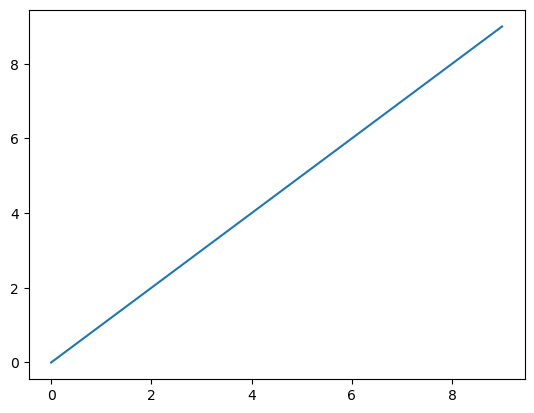

In [13]:
plt.plot(data)

----

##### ✅ Reason for the Error: `Javascript Error: IPython is not defined`

This happens because of this line (from the book / notebook):

```python
%matplotlib notebook
```

👉 The **`notebook` backend uses old Jupyter Javascript APIs (`IPython`)** to make plots interactive.

In **new Jupyter / JupyterLab / modern notebook environments**, this JS object is **not available → so browser throws:**

```
Javascript Error: IPython is not defined
```

---

##### ⭐ Important: Your Plot Actually Worked

You can see:

```
[<matplotlib.lines.Line2D ...>]
```

This means:

✅ matplotlib DID create the plot
❌ only the **interactive frontend failed**

So this is a **frontend backend issue — not a Python plotting error.**

---

##### ⭐ Correct Modern Fix

Use:

```python
%matplotlib inline
```

OR (best modern interactive option):

```python
%matplotlib widget
```

---

##### ⭐ When to Use What

| Backend    | Use Case                           |
| ---------- | ---------------------------------- |
| `inline`   | simple static plots (most DS work) |
| `widget`   | zoom / pan / interactive plots     |
| `notebook` | OLD — avoid now                    |

---

##### ⭐ Why Books Still Show `%matplotlib notebook`

Older versions of:

* Jupyter Notebook
* matplotlib
* IPython

used this as the main interactive backend.

Modern stack moved to:

👉 **ipympl (`widget` backend)**

---

##### ✅ Final Recommendation

Just run once at top:

```python
%matplotlib inline
```

Then:

```python
plt.plot(data)
plt.show()
```

---

While libraries like seaborn and pandas’s built-in plotting functions will deal with
many of the mundane details of making plots, should you wish to customize them
beyond the function options provided, you will need to learn a bit about the matplotlib
API.

> **There is not enough room in the book to give a comprehensive
treatment to the breadth and depth of functionality in matplotlib. It
should be enough to teach you the ropes to get up and running.
The matplotlib gallery and documentation are the best resource for
learning advanced features**

---

### Figures and Subplots

Plots in `matplotlib` reside within a `Figure` object. You can create a new figure with
`plt.figure`:

In [14]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In IPython, an empty plot window will appear, but in Jupyter nothing will be shown
until we use a few more commands. `plt.figure` has a number of options; notably,
`figsize` will guarantee the figure has a certain size and aspect ratio if saved to disk.

You can’t make a plot with a blank figure. You have to create one or more subplots
using `add_subplot`:

In [16]:
ax1 = fig.add_subplot(2, 2, 1)

This means that the figure should be 2 × 2 (so up to four plots in total), and we’re
selecting the first of four subplots (numbered from 1). If you create the next two subplots,
you’ll end up with a visualization that looks like Figure below

In [18]:
ax2 = fig.add_subplot(2, 2, 2)

In [19]:
ax3 = fig.add_subplot(2, 2, 3)

> One nuance of using Jupyter notebooks is that plots are reset after
each cell is evaluated, so for more complex plots you must put all of
the plotting commands in a single notebook cell.

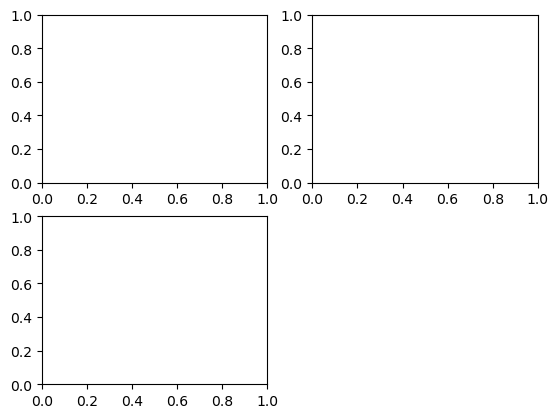

In [20]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

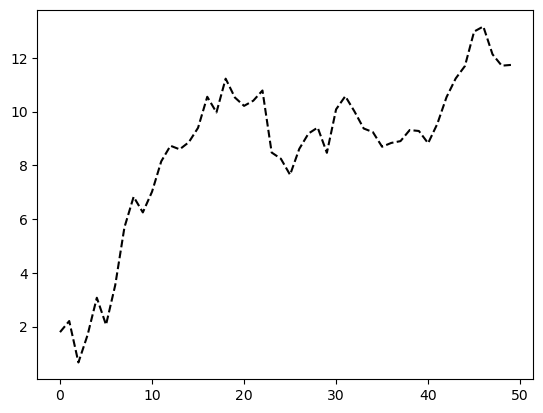

In [21]:
plt.plot(np.random.randn(50).cumsum(), 'k--')

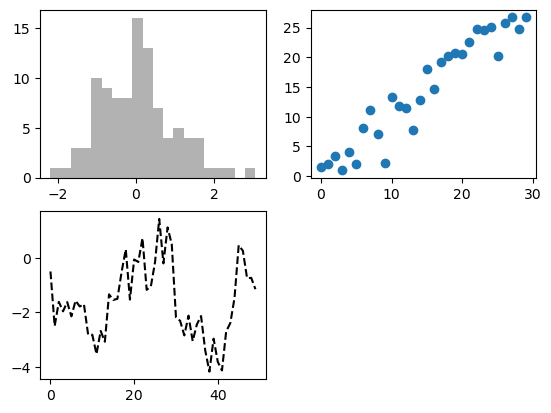

In [27]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax1.hist(np.random.randn(100), bins=20, color='k', alpha=0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30))
ax3.plot(np.random.randn(50).cumsum(), 'k--')


You can find a comprehensive catalog of plot types in the matplotlib documentation. (https://matplotlib.org/)

---

Creating a figure with a grid of subplots is a very common task, so matplotlib
includes a convenience method, `plt.subplots`, that creates a new figure and returns
a NumPy array containing the created subplot objects:

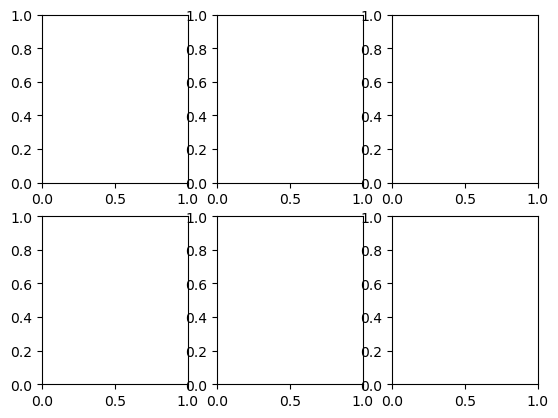

In [56]:
fig, axes = plt.subplots(2, 3)

In [29]:
axes

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

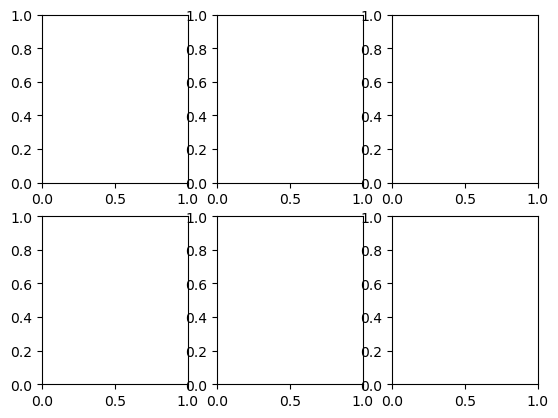

In [30]:
fig

This is very useful, as the axes array can be easily indexed like a two-dimensional
array; for example, `axes[0, 1]`. You can also indicate that subplots should have the
same x- or y-axis using sharex and sharey, respectively. This is especially useful
when you’re comparing data on the same scale; otherwise, matplotlib autoscales plot
limits independently. See Table 9-1 for more on this method.

In [31]:
columns = ["Argument", "Description"]

rows = [
["nrows","Number of rows of subplots"],
["ncols","Number of columns of subplots"],
["sharex","All subplots use the same x-axis ticks; changing xlim affects all"],
["sharey","All subplots use the same y-axis ticks; changing ylim affects all"],
["subplot_kw","Dict of keywords passed to add_subplot when creating each subplot"],
["**fig_kw","Additional keywords used when creating the figure (e.g., figsize=(8,6))"]
]

render_book_table(
    "Table 9-1. pyplot.subplots Options",
    columns,
    rows
)

Argument,Description
nrows,Number of rows of subplots
ncols,Number of columns of subplots
sharex,All subplots use the same x-axis ticks; changing xlim affects all
sharey,All subplots use the same y-axis ticks; changing ylim affects all
subplot_kw,Dict of keywords passed to add_subplot when creating each subplot
**fig_kw,"Additional keywords used when creating the figure (e.g., figsize=(8,6))"


---

Adjusting the spacing around subplots
By default matplotlib leaves a certain amount of padding around the outside of the
subplots and spacing between subplots. This spacing is all specified relative to the
height and width of the plot, so that if you resize the plot either programmatically or
manually using the GUI window, the plot will dynamically adjust itself. You can
change the spacing using the `subplots_adjust` method on `Figure` objects, also available
as a top-level function:

`wspace` and `hspace` controls the percent of the figure width and figure height, respectively,
to use as spacing between subplots. Here is a small example where I shrink the
spacing all the way to zero

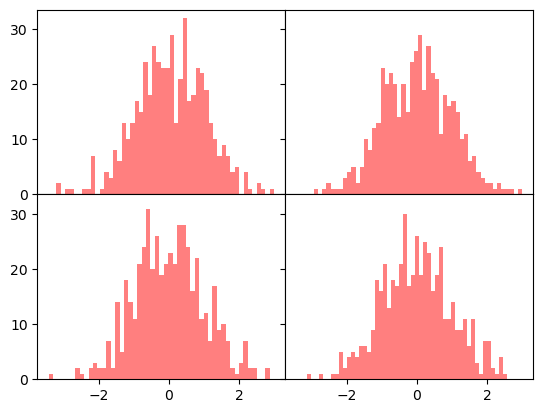

In [42]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='r', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

You may notice that the axis labels overlap. matplotlib doesn’t check whether the
labels overlap, so in a case like this you would need to fix the labels yourself by specifying
explicit tick locations and tick labels (we’ll look at how to do this in the following
sections).

---

### Colors, Markers, and Line Styles

Matplotlib’s main `plot` function accepts arrays of x and y coordinates and optionally a
string abbreviation indicating color and line style. For example, to plot x versus y
with green dashes, you would execute:

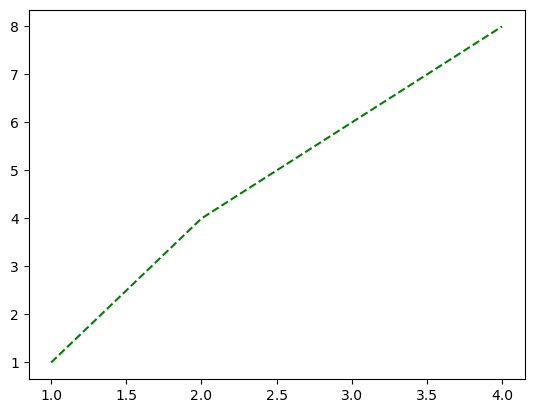

In [58]:
fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
x=[1,2,3,4]
y=[1,4,6,8]
ax1.plot(x, y, 'g--')


This way of specifying both color and line style in a string is provided as a convenience;
in practice if you were creating plots programmatically you might prefer not
to have to munge strings together to create plots with the desired style. The same plot
could also have been expressed more explicitly as:

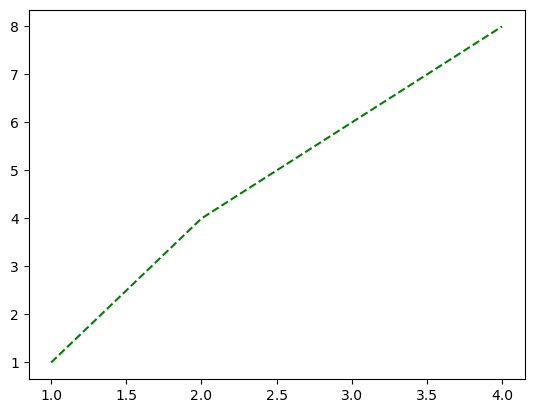

In [60]:

fig1 = plt.figure()
ax1 = fig1.add_subplot(1, 1, 1)
x=[1,2,3,4]
y=[1,4,6,8]
ax1.plot(x, y, linestyle='--', color='g')

There are a number of color abbreviations provided for commonly used colors, but
you can use any color on the spectrum by specifying its hex code (e.g., `'#CECECE'`).
You can see the full set of line styles by looking at the docstring for `plot` (use `plot?` in
IPython or Jupyter).
9.1

plt.plot?

Line plots can additionally have markers to highlight the actual data points. Since
matplotlib creates a continuous line plot, interpolating between points, it can occasionally
be unclear where the points lie. The marker can be part of the style string,
which must have color followed by marker type and line style

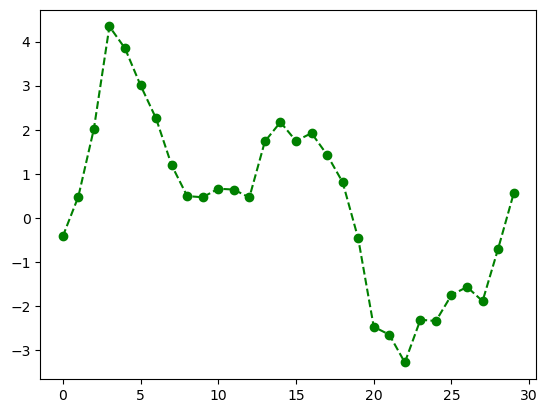

In [50]:
from numpy.random import randn
plt.plot(randn(30).cumsum(), 'go--')

This could also have been written more explicitly as:

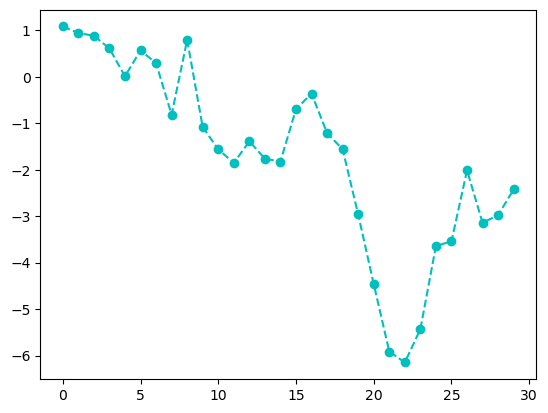

In [63]:
plt.plot(randn(30).cumsum(), color='c', linestyle='dashed', marker='o')

For line plots, you will notice that subsequent points are linearly interpolated by
default. This can be altered with the `drawstyle` option (Figure 9-7):

In [64]:
data = np.random.randn(30).cumsum()

In [65]:
data

array([-0.09966254,  0.53322151,  1.15764539,  1.70545082,  1.19526818,
        1.4452619 ,  1.91017612,  3.18667889,  2.70213831,  2.77347403,
        1.11574323,  0.10320888,  0.80062352,  1.67905907,  2.47733734,
        2.7424754 ,  0.29002316,  0.98834551, -0.31154163,  0.50242283,
        0.16518882,  0.48970131, -1.00606867, -0.73863265,  0.7367649 ,
        0.87875923, -1.20150163, -0.38215231, -1.71193817, -2.56625688])

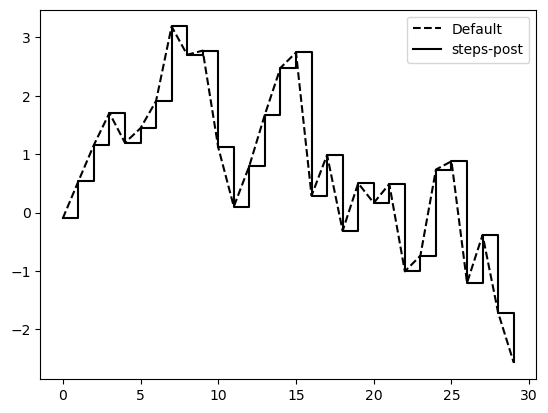

In [70]:
plt.plot(data, 'k--', label='Default')
plt.plot(data, 'k-', drawstyle='steps-post', label='steps-post')
plt.legend(loc='best')

You may notice output like <matplotlib.lines.Line2D at ...> when you run this.
`matplotlib` returns objects that reference the plot subcomponent that was just added.
A lot of the time you can safely ignore this output. Here, since we passed the label
arguments to plot, we are able to create a plot legend to identify each line using
`plt.legend`.

> You must call `plt.legend` (or `ax.legend`, if you have a reference to
the axes) to create the legend, whether or not you passed the label
options when plotting the data.

### Ticks, Labels, and Legends

For most kinds of plot decorations, there are two main ways to do things: using the
procedural `pyplot` interface (i.e., `matplotlib.pyplot`) and the more object-oriented
native matplotlib API.

The `pyplot` interface, designed for interactive use, consists of methods like `xlim`,
`xticks`, and `xticklabels`. These control the plot range, tick locations, and tick labels,
respectively. They can be used in two ways:

Called with no arguments returns the current parameter value (e.g., `plt.xlim()`
returns the current x-axis plotting range)
• Called with parameters sets the parameter value (e.g., `plt.xlim([0, 10]`), sets
the x-axis range to 0 to 10)

All such methods act on the active or most recently created `AxesSubplot`. Each of
them corresponds to two methods on the `subplot` object itself; in the case of xlim
these are `ax.get_xlim` and `ax.set_xlim`. I prefer to use the subplot instance methods
myself in the interest of being explicit (and especially when working with multiple
subplots), but you can certainly use whichever you find more convenient.

#### Setting the title, axis labels, ticks, and ticklabels

To illustrate customizing the axes, I’ll create a simple figure and plot of a random
walk

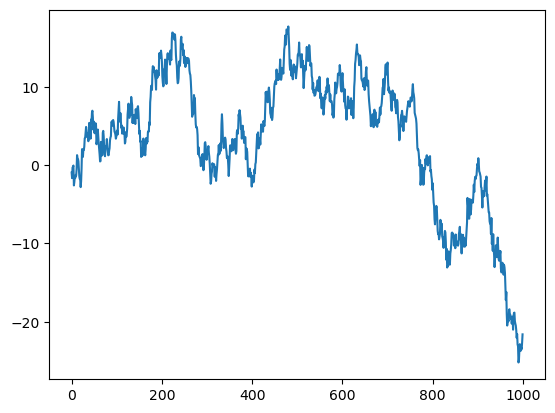

In [75]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())

To change the x-axis ticks, it’s easiest to use `set_xticks` and `set_xticklabels`. The
former instructs `matplotlib` where to place the ticks along the data range; by default these locations will also be the labels. But we can set any other values as the labels
using `set_xticklabels`:

The `rotation` option sets the x tick labels at a 30-degree rotation. Lastly, `set_xlabel`
gives a name to the x-axis and set_title the subplot title

Modifying the y-axis consists of the same process, substituting y for x in the above.
The axes class has a set method that allows batch setting of plot properties. From the
prior example, we could also have written:



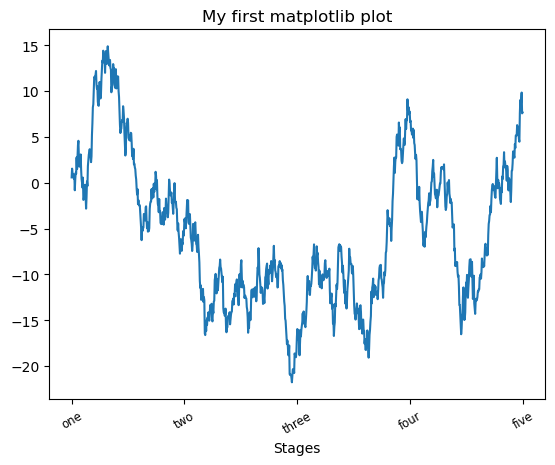

In [81]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],rotation=30, fontsize='small')
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')
ax.plot(np.random.randn(1000).cumsum())

#### Adding legends

Legends are another critical element for identifying plot elements. There are a couple
of ways to add one. The easiest is to pass the label argument when adding each piece
of the plot:

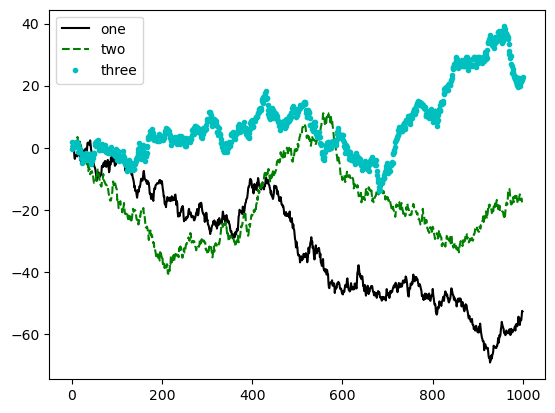

In [93]:
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'g--', label='two')
ax.plot(randn(1000).cumsum(), 'c.', label='three')
ax.legend(loc='best')

The `legend` method has several other choices for the location loc argument. See the
docstring (with `ax.legend?`) for more information.

In [94]:
ax.legend?

Signature: ax.legend(*args, **kwargs)
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for all
    artist

The `loc` tells matplotlib where to place the plot. If you aren’t picky, `'best'` is a good
option, as it will choose a location that is most out of the way. To exclude one or more
elements from the legend, pass no label or label=`'_nolegend_'`.

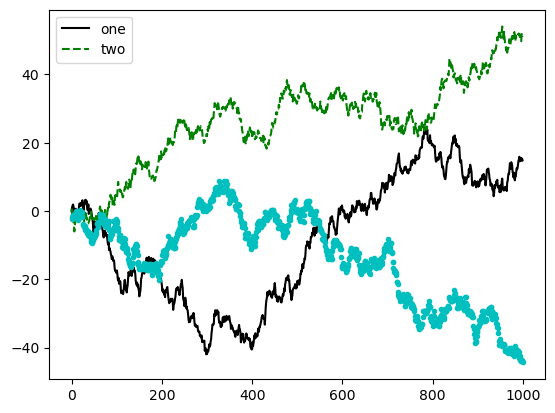

In [96]:
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'g--', label='two')
ax.plot(randn(1000).cumsum(), 'c.', label='_nolegend_')
ax.legend(loc='best')

#### Annotations and Drawing on a Subplot

In addition to the standard plot types, you may wish to draw your own plot annotations,
which could consist of text, arrows, or other shapes. You can add annotations
and text using the `text`, `arrow`, and `annotate` functions. `text` draws text at given
coordinates (x, y) on the plot with optional custom styling:

Text(0, 40, 'Hello world!')

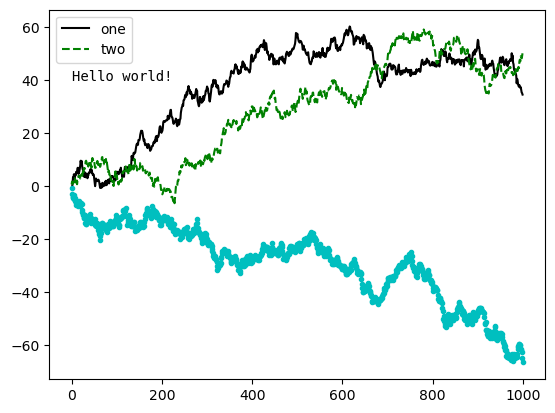

In [103]:
x=0
y=40

fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label='one')
ax.plot(randn(1000).cumsum(), 'g--', label='two')
ax.plot(randn(1000).cumsum(), 'c.', label='_nolegend_')
ax.legend(loc='best')
ax.text(x, y, 'Hello world!',family='monospace', fontsize=10)


Annotations can draw both text and arrows arranged appropriately. As an example,
let’s plot the closing S&P 500 index price since 2007 (obtained from Yahoo! Finance)
and annotate it with some of the important dates from the 2008–2009 financial crisis.
You can most easily reproduce this code example in a single cell in a Jupyter notebook.

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

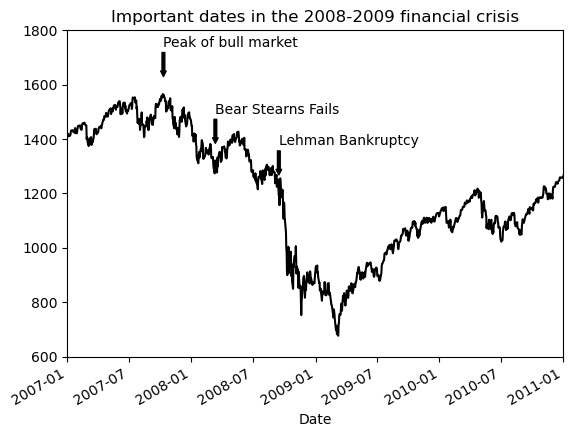

In [107]:
from datetime import datetime
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
data = pd.read_csv('examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']
spx.plot(ax=ax, style='k-')
crisis_data = [
(datetime(2007, 10, 11), 'Peak of bull market'),
(datetime(2008, 3, 12), 'Bear Stearns Fails'),
(datetime(2008, 9, 15), 'Lehman Bankruptcy')
]
for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
    xytext=(date, spx.asof(date) + 225),
    arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
    horizontalalignment='left', verticalalignment='top')

ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])
ax.set_title('Important dates in the 2008-2009 financial crisis')

There are a couple of important points to highlight in this plot: the `ax.annotate`
method can draw labels at the indicated x and y coordinates. We use the `set_xlim`
and `set_ylim` methods to manually set the start and end boundaries for the plot
rather than using matplotlib’s default. Lastly, `ax.set_title` adds a main title to the
plot.

See the online matplotlib gallery for many more annotation examples to learn from.

Drawing shapes requires some more care. matplotlib has objects that represent many
common shapes, referred to as patches. Some of these, like Rectangle and Circle, are
found in `matplotlib.pyplot`, but the full set is located in `matplotlib.patches`.

To add a shape to a plot, you create the patch object `shp` and add it to a subplot by
calling `ax.add_patch(shp)`

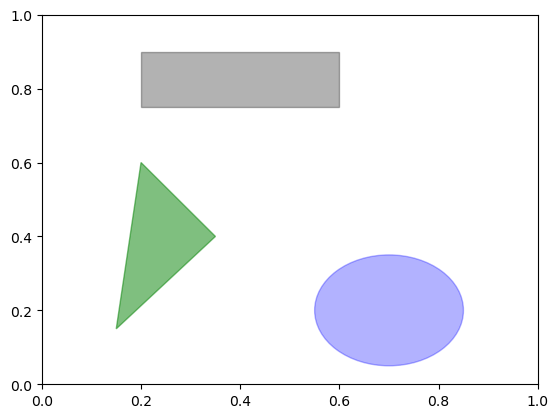

In [110]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
color='g', alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

If you look at the implementation of many familiar plot types, you will see that they
are assembled from patches.

### Saving Plots to File

You can save the active figure to file using `plt.savefig`. This method is equivalent to
the figure object’s savefig instance method. For example, to save an SVG version of a
figure, you need only type:

The file type is inferred from the file extension. So if you used `.pdf` instead, you
would get a PDF. There are a couple of important options that I use frequently for
publishing graphics: `dpi`, which controls the dots-per-inch resolution, and
`bbox_inches`, which can trim the whitespace around the actual figure. To get the
same plot as a PNG with minimal whitespace around the plot and at 400 DPI, you
would do:

In [112]:
plt.savefig('figpath.png', dpi=400, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

`savefig` doesn’t have to write to disk; it can also write to any file-like object, such as a
'BytesIO':

In [114]:
from io import BytesIO
buffer = BytesIO()
plt.savefig(buffer)
plot_data = buffer.getvalue()

<Figure size 640x480 with 0 Axes>

See Table 9-2 for a list of some other options for `savefig`.




In [115]:
columns = ["Argument", "Description"]

rows = [
["fname","File path string or file-like object; format inferred from extension (e.g., .png, .pdf)"],
["dpi","Figure resolution in dots per inch; default is 100"],
["facecolor / edgecolor","Background color of the figure outside subplots; default is white"],
["format","Explicit file format such as 'png', 'pdf', 'svg', 'ps', 'eps'"],
["bbox_inches","Portion of figure to save; 'tight' trims extra whitespace"]
]

render_book_table(
    "Table 9-2. Figure.savefig Options",
    columns,
    rows
)

Argument,Description
fname,"File path string or file-like object; format inferred from extension (e.g., .png, .pdf)"
dpi,Figure resolution in dots per inch; default is 100
facecolor / edgecolor,Background color of the figure outside subplots; default is white
format,"Explicit file format such as 'png', 'pdf', 'svg', 'ps', 'eps'"
bbox_inches,Portion of figure to save; 'tight' trims extra whitespace


### matplotlib Configuration

matplotlib comes configured with color schemes and defaults that are geared primarily
toward preparing figures for publication. Fortunately, nearly all of the default
behavior can be customized via an extensive set of global parameters governing figure
size, subplot spacing, colors, font sizes, grid styles, and so on. One way to modify the
configuration programmatically from Python is to use the `rc` method; for example, to
set the global default figure size to be 10 × 10, you could enter:

In [117]:
plt.rc('figure', figsize=(10, 10))

The first argument to rc is the component you wish to customize, such as 'figure',
`'axes'`, `'xtick'`, `'ytick'`, `'grid'`, `'legend`', or many others. After that can follow a
sequence of keyword arguments indicating the new parameters. An easy way to write
down the options in your program is as a dict:

In [119]:
font_options = {'family' : 'monospace',
'weight' : 'bold',
'size' : 'small'}
plt.rc('font', **font_options)

ValueError: Key font.size: Could not convert 'small' to float

In [120]:
font_options = {
    'family': 'monospace',
    'weight': 'bold',
    'size': 10
}

plt.rc('font', **font_options)

----

##### ✅ **Reason for this Error**

The error is very clear from the last line:

```
ValueError: Key font.size: Could not convert 'small' to float
```

👉 In **Matplotlib `rcParams`**, the parameter:

```
font.size
```

**expects a numeric value (float / int)** — not a string like `"small"`.

---

##### ✅ **Why this Happens**

You wrote:

```python
font_options = {
    'family': 'monospace',
    'weight': 'bold',
    'size': 'small'
}
plt.rc('font', **font_options)
```

Internally Matplotlib tries to set:

```
rcParams['font.size'] = 'small'
```

But Matplotlib validates this and says:

> ❌ I cannot convert `"small"` → float

Hence the error.

---

##### ✅ **Correct Fix**

Use a **number instead of `'small'`**

Example:

```python
font_options = {
    'family': 'monospace',
    'weight': 'bold',
    'size': 10
}

plt.rc('font', **font_options)
```

---

##### ✅ **Very Important Concept (Senior-level Understanding)**

Matplotlib has **two different styling worlds**

### ⭐ World-1 → Numeric rcParams (Global Config)

These require **exact numeric values**

Examples:

```
font.size
lines.linewidth
figure.dpi
```

These are stored in:

```
matplotlib.rcParams
```

They are **strictly validated**

---

### ⭐ World-2 → Text Properties (Local Plot Usage)

Here you *can* use relative sizes like:

```
'small'
'large'
'x-large'
```

Example:

```python
plt.title("My Plot", fontsize='small')
```

This works because text objects support **relative font scaling**.

But `rc()` global config does NOT.

---

##### ✅ **Better Modern Practice**

Instead of `plt.rc()` you can also use:

```python
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 10
```

This is:

✔ clearer
✔ explicit
✔ easier to debug
✔ widely used in production notebooks

---




For more extensive customization and to see a list of all the options, matplotlib comes
with a configuration file matplotlibrc in the matplotlib/mpl-data directory. If you customize
this file and place it in your home directory titled .matplotlibrc, it will be
loaded each time you use matplotlib.

As we’ll see in the next section, the seaborn package has several built-in plot themes
or styles that use matplotlib’s configuration system internally.m

---

## 9.2 Plotting with pandas and seaborn

matplotlib can be a fairly low-level tool. You assemble a plot from its base components:
the data display (i.e., the type of plot: line, bar, box, scatter, contour, etc.), legend,
title, tick labels, and other annotations.

In pandas we may have multiple columns of data, along with row and column labels.
pandas itself has built-in methods that simplify creating visualizations from Data‐
Frame and Series objects. Another library is seaborn, a statistical graphics library created
by Michael Waskom. `Seaborn` simplifies creating many common visualization
types.

> Importing seaborn modifies the default matplotlib color schemes
and plot styles to improve readability and aesthetics. Even if you do
not use the seaborn API, you may prefer to import seaborn as a
simple way to improve the visual aesthetics of general matplotlib
plots.

### Line Plots

Series and DataFrame each have a plot attribute for making some basic plot types. By
default, `plot()` makes line plots

In [125]:
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))

In [127]:
s

0     1.426870
10    1.862044
20    1.958320
30    0.128501
40    2.492190
50    3.990352
60    2.621790
70    1.303616
80    2.724177
90    2.800601
dtype: float64

<Axes: >

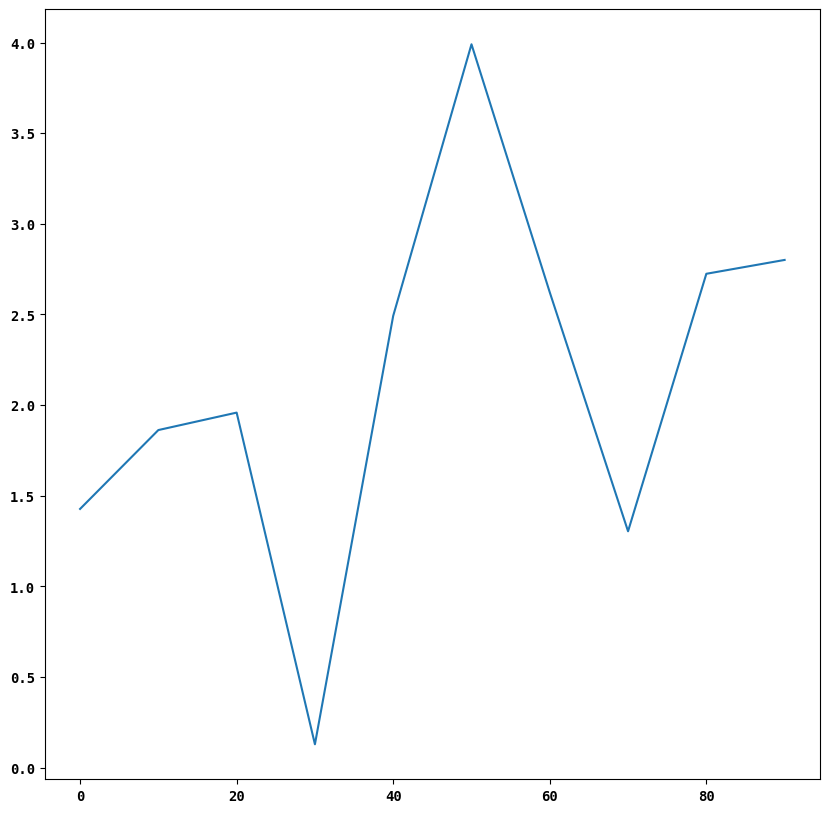

In [128]:
s.plot()

The Series object’s index is passed to matplotlib for plotting on the x-axis, though you
can disable this by passing `use_index=False`. The x-axis ticks and limits can be
adjusted with the `xticks` and `xlim` options, and y-axis respectively with `yticks` and ylim. See Table 9-3 for a full listing of plot options. I’ll comment on a few more of
them throughout this section and leave the rest to you to explore.

In [129]:
columns = ["Argument", "Description"]
rows = [
    ["label", "Label for plot legend"],
    ["ax", "matplotlib subplot object to plot on; if nothing passed, uses active matplotlib subplot"],
    ["style", "Style string, like 'ko--', to be passed to matplotlib"],
    ["alpha", "The plot fill opacity (from 0 to 1)"],
    ["kind", "Can be 'area', 'bar', 'barh', 'density', 'hist', 'kde', 'line', 'pie'"],
    ["logy", "Use logarithmic scaling on the y-axis"],
    ["use_index", "Use the object index for tick labels"],
    ["rot", "Rotation of tick labels (0 through 360)"],
    ["xticks", "Values to use for x-axis ticks"],
    ["yticks", "Values to use for y-axis ticks"],
    ["xlim", "x-axis limits (e.g., [0, 10])"],
    ["ylim", "y-axis limits"],
    ["grid", "Display axis grid (on by default)"],
]

# Render the table
render_book_table("Table 9-3. Series.plot method arguments", columns, rows)

Argument,Description
label,Label for plot legend
ax,"matplotlib subplot object to plot on; if nothing passed, uses active matplotlib subplot"
style,"Style string, like 'ko--', to be passed to matplotlib"
alpha,The plot fill opacity (from 0 to 1)
kind,"Can be 'area', 'bar', 'barh', 'density', 'hist', 'kde', 'line', 'pie'"
logy,Use logarithmic scaling on the y-axis
use_index,Use the object index for tick labels
rot,Rotation of tick labels (0 through 360)
xticks,Values to use for x-axis ticks
yticks,Values to use for y-axis ticks


Most of pandas’s plotting methods accept an optional `ax` parameter, which can be a
matplotlib subplot object. This gives you more flexible placement of subplots in a grid
layout.

DataFrame’s `plot` method plots each of its columns as a different line on the same
subplot, creating a legend automatically

In [130]:
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))

In [131]:
df

,A,B,C,D
0,0.414510,0.153042,1.655126,-2.277690
10,-0.002891,-0.471872,0.624599,-3.042617
20,-1.926141,0.032244,-0.689147,-3.484123
30,-1.393704,1.919597,0.021254,-4.832908
40,-2.830129,1.714503,2.755158,-5.362930
50,-2.430264,1.290082,1.903556,-5.297760
60,-2.464147,1.365120,1.507934,-4.803539
70,-2.060876,1.297863,2.564271,-4.505778
80,-2.753967,0.097432,1.383220,-3.435929
90,-4.163490,-0.887747,1.817388,-3.822671


<Axes: >

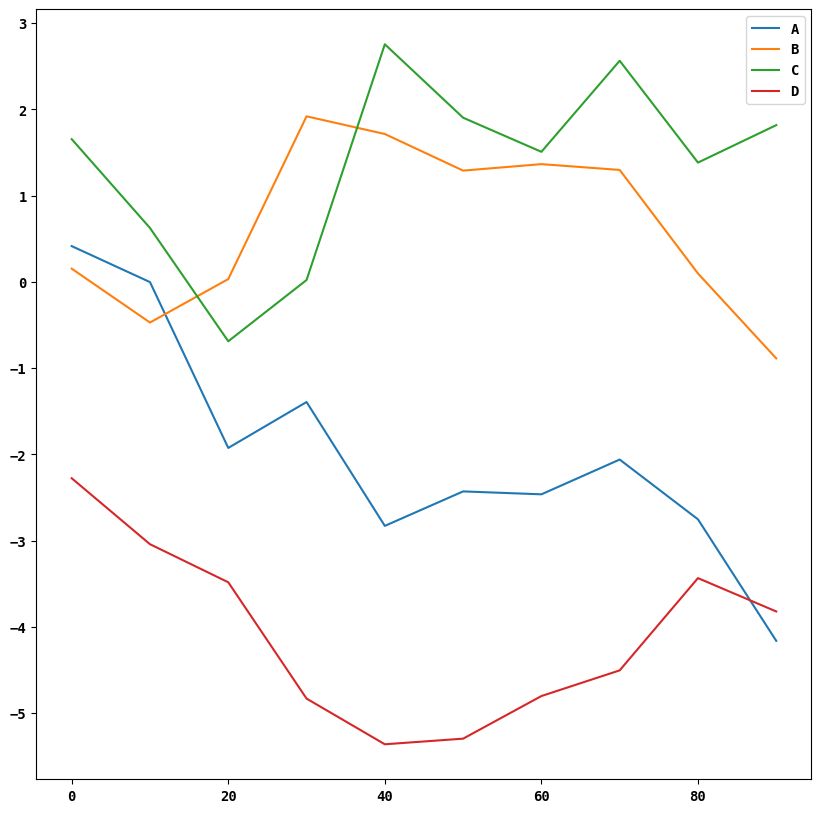

In [132]:
df.plot()

The plot attribute contains a “family” of methods for different plot types. For example,
`df.plot()` is equivalent to `df.plot.line()`. We’ll explore some of these methods
next.

Additional keyword arguments to `plot` are passed through to the
respective matplotlib plotting function, so you can further customize
these plots by learning more about the matplotlib API.

DataFrame has a number of options allowing some flexibility with how the columns
are handled; for example, whether to plot them all on the same subplot or to create
separate subplots. See Table 9-4 for more on these.

In [135]:
# Table data
columns = ["Argument", "Description"]
rows = [
    ["subplots", "Plot each DataFrame column in a separate subplot"],
    ["sharex", "If subplots=True, share the same x-axis, linking ticks and limits"],
    ["sharey", "If subplots=True, share the same y-axis"],
    ["figsize", "Size of figure to create as tuple"],
    ["title", "Plot title as string"],
    ["legend", "Add a subplot legend (True by default)"],
    ["sort_columns", "Plot columns in alphabetical order; by default uses existing column order"],
]

# Render the table
render_book_table("Table 9-4. DataFrame-specific plot arguments", columns, rows)

Argument,Description
subplots,Plot each DataFrame column in a separate subplot
sharex,"If subplots=True, share the same x-axis, linking ticks and limits"
sharey,"If subplots=True, share the same y-axis"
figsize,Size of figure to create as tuple
title,Plot title as string
legend,Add a subplot legend (True by default)
sort_columns,Plot columns in alphabetical order; by default uses existing column order


In [136]:
title = "Table 9-4. DataFrame-specific plot arguments"

columns = ["Argument", "Description"]

rows = [
    ["`subplots`", "Plot each DataFrame column in a separate subplot"],
    ["`sharex`", "If subplots=True, share the same x-axis, linking ticks and limits"],
    ["`sharey`", "If subplots=True, share the same y-axis"],
    ["`figsize`", "Size of figure to create as tuple"],
    ["`title`", "Plot title as string"],
    ["`legend`", "Add a subplot legend (True by default)"],
    ["`sort_columns`", "Plot columns in alphabetical order; by default uses existing column order"],
]

render_book_table(title, columns, rows)

Argument,Description
`subplots`,Plot each DataFrame column in a separate subplot
`sharex`,"If subplots=True, share the same x-axis, linking ticks and limits"
`sharey`,"If subplots=True, share the same y-axis"
`figsize`,Size of figure to create as tuple
`title`,Plot title as string
`legend`,Add a subplot legend (True by default)
`sort_columns`,Plot columns in alphabetical order; by default uses existing column order


### Bar Plots

The `plot.bar()` and `plot.barh()` make vertical and horizontal bar plots, respectively.
In this case, the Series or DataFrame index will be used as the x (`bar`) or y
(`barh`) ticks

<Axes: >

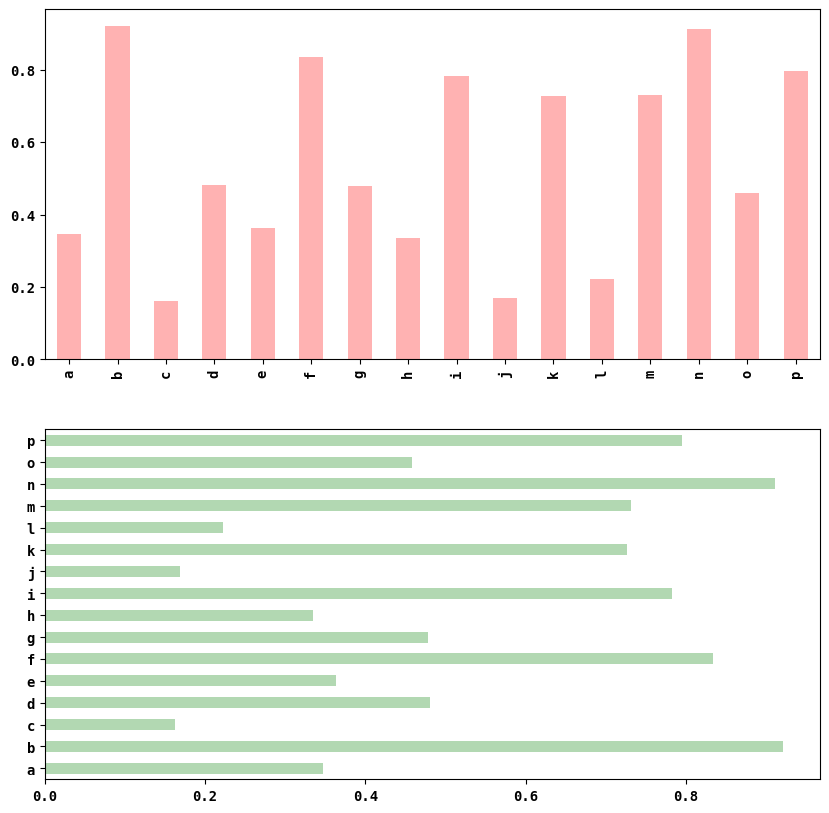

In [140]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='r', alpha=0.3)
data.plot.barh(ax=axes[1], color='g', alpha=0.3)

The options `color='k'` and `alpha=0.3` set the color of the plots to black and use partial
transparency on the filling.

---

With a DataFrame, bar plots group the values in each row together in a group in bars,
side by side, for each value.

In [141]:
df = pd.DataFrame(np.random.rand(6, 4),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))

In [143]:
df

Genus,A,B,C,D
one,0.212017,0.824560,0.176174,0.162713
two,0.846683,0.318646,0.567425,0.889206
three,0.389642,0.260175,0.037451,0.637509
four,0.094316,0.117503,0.624359,0.520436
five,0.280719,0.204108,0.726695,0.319544
six,0.009120,0.496707,0.318528,0.781620


<Axes: >

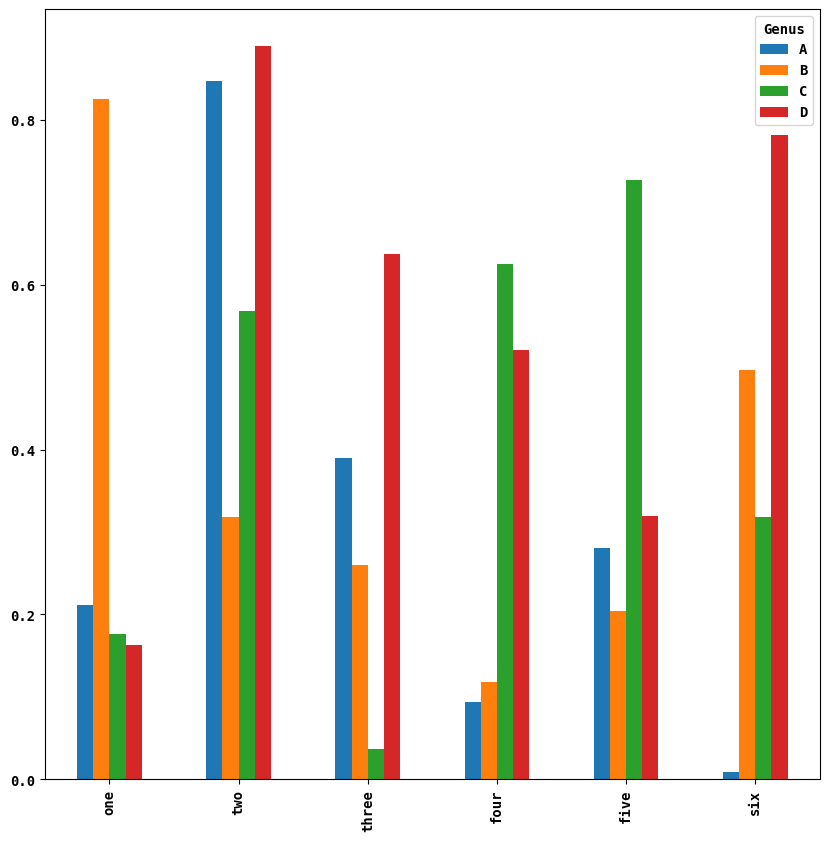

In [144]:
df.plot.bar()

Note that the name `“Genus”` on the DataFrame’s columns is used to title the legend.

We create stacked bar plots from a DataFrame by passing `stacked=True`, resulting in
the value in each row being stacked together

<Axes: >

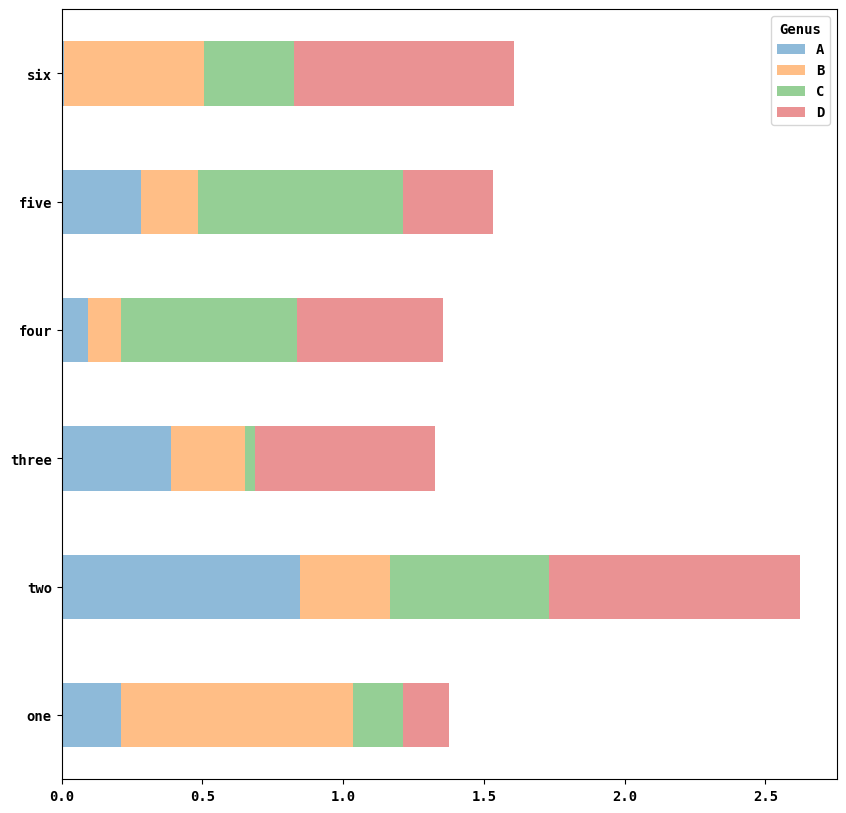

In [145]:
df.plot.barh(stacked=True, alpha=0.5)

---

A useful recipe for bar plots is to visualize a Series’s value frequency
using `value_counts`: `s.value_counts().plot.bar()`.

In [151]:
s = pd.Series(np.random.randint(1, 11, size=1000))

In [152]:
s.value_counts()

9     110
3     109
4     108
7     107
5     103
10    102
6      93
1      93
2      91
8      84
Name: count, dtype: int64

<Axes: >

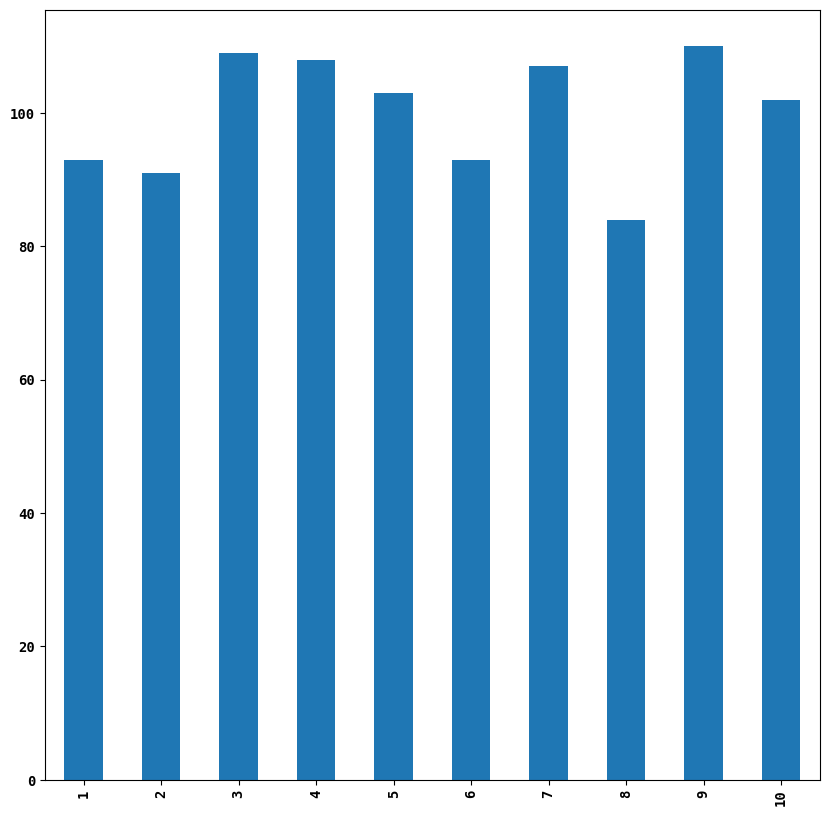

In [153]:
s.value_counts().sort_index().plot.bar()

----

Returning to the tipping dataset used earlier in the book, suppose we wanted to make
a stacked bar plot showing the percentage of data points for each party size on each
day. I load the data using `read_csv` and make a cross-tabulation by day and party size:

In [154]:
tips = pd.read_csv('examples/tips.csv')

In [155]:
party_counts = pd.crosstab(tips['day'], tips['size'])

In [156]:
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [157]:
party_counts = party_counts.loc[:, 2:5]

In [158]:
party_counts

size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


Then, normalize so that each row sums to 1 and make the plot

In [160]:
party_pcts = party_counts.div(party_counts.sum(1), axis=0)

In [161]:
party_pcts

size,2,3,4,5
day,,,,
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000
Thur,0.827586,0.068966,0.086207,0.017241


<Axes: xlabel='day'>

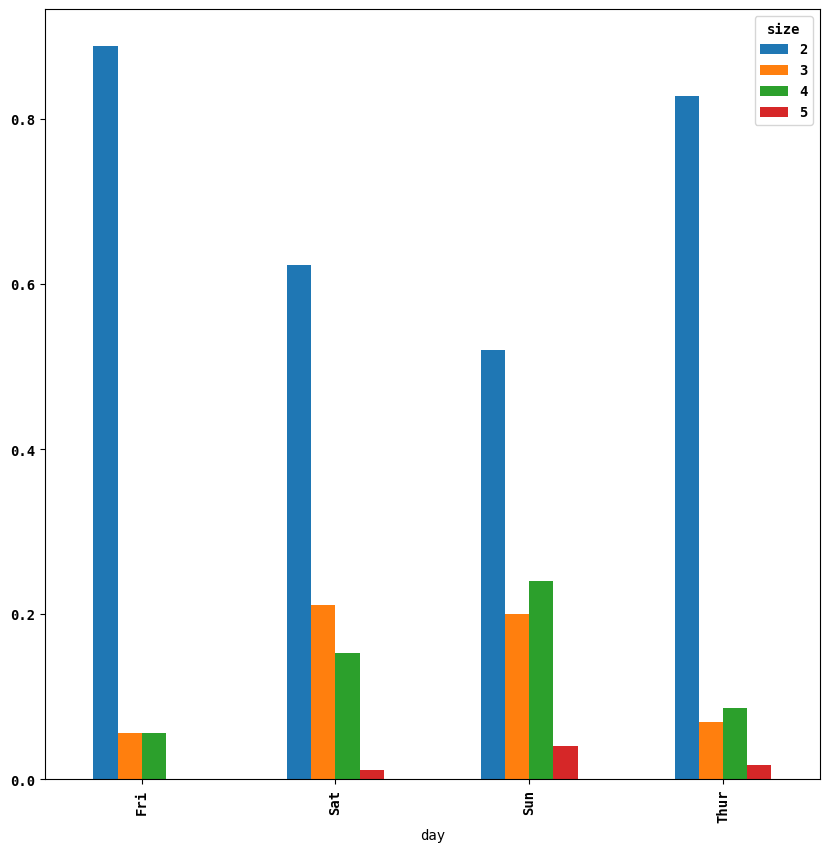

In [162]:
party_pcts.plot.bar()

So you can see that party sizes appear to increase on the weekend in this dataset.

---

With data that requires aggregation or summarization before making a plot, using the
`seaborn` package can make things much simpler. Let’s look now at the tipping percentage
by day with seaborn

Plotting functions in `seaborn` take a data argument, which can be a pandas Data‐
Frame. The other arguments refer to column names. Because there are multiple
observations for each value in the day, the bars are the average value of tip_pct. The
black lines drawn on the bars represent the 95% confidence interval (this can be configured
through optional arguments).

In [163]:
import seaborn as sns

In [164]:
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])

In [166]:
tips

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,0.256166
240,27.18,2.00,Yes,Sat,Dinner,2,0.079428
241,22.67,2.00,Yes,Sat,Dinner,2,0.096759
242,17.82,1.75,No,Sat,Dinner,2,0.108899


<Axes: xlabel='tip_pct', ylabel='day'>

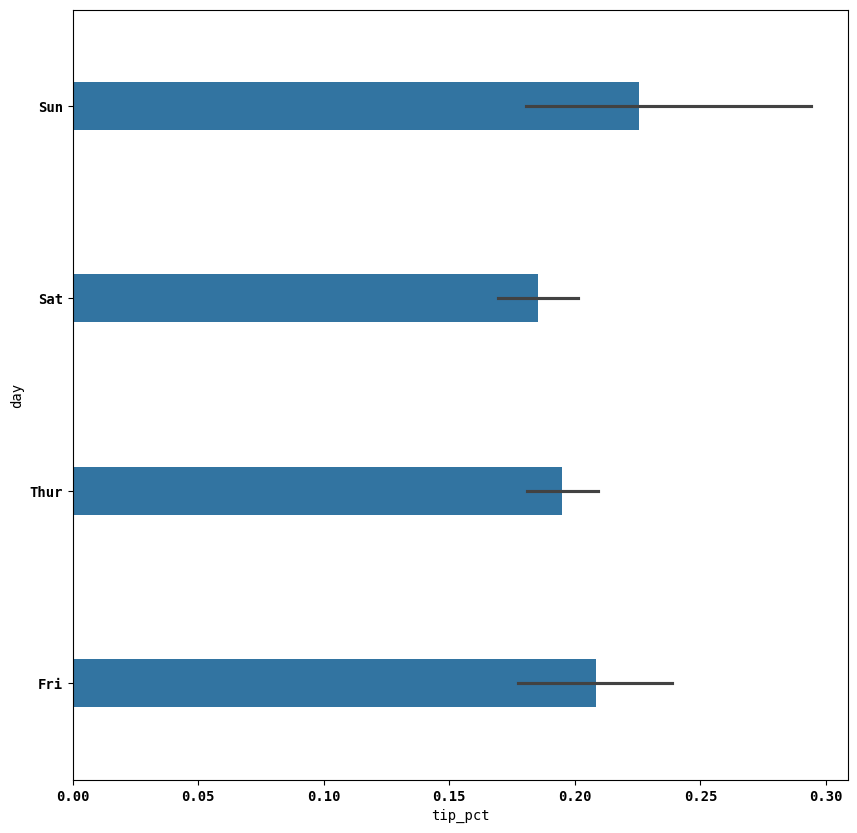

In [169]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h',width=0.25)

##### Summary

Yes—`seaborn.barplot` **aggregates** the numeric variable by the categorical variable and, by default, plots the **mean** (average) of that numeric variable for each category. In your example:

```python
sns.barplot(x='tip_pct', y='day', data=tips, orient='h', width=0.25)
```

each horizontal bar represents the **average `tip_pct` for that `day`**.

##### What Seaborn Computes by Default

*   **Estimator (summary statistic):** Arithmetic mean (`np.mean`).
*   **Uncertainty interval:** 95% confidence interval via bootstrapping.
    *   In Seaborn **≥ 0.12**: control with `errorbar=('ci', 95)` or disable with `errorbar=None`.
    *   In **older versions**: control with `ci=95` or disable with `ci=None`.

So, unless you change `estimator=` or turn off intervals, you’re seeing the **mean tip percentage per day** with **error bars** showing uncertainty.

##### How to Change the Aggregation

You can replace the mean with any function (e.g., median, sum, count, custom functions):

```python
import numpy as np
import seaborn as sns

# Median instead of mean
sns.barplot(
    x='tip_pct', y='day', data=tips, orient='h',
    estimator=np.median, errorbar=None, width=0.25
)

# Sum per day
sns.barplot(
    x='tip_pct', y='day', data=tips, orient='h',
    estimator=np.sum, errorbar=None
)
```

If you want **no aggregation** (i.e., plot raw values), `barplot` isn’t the right choice—use a **stripplot**, **swarmplot**, or switch to **pointplot/catplot** variants for different summaries.

##### Pre-Aggregating Yourself (Optional)

If you prefer full control, compute the statistic first and then plot:

```python
import pandas as pd
import seaborn as sns

grp = (
    tips.groupby('day', as_index=False)
        .agg(tip_pct_mean=('tip_pct', 'mean'))
)

sns.barplot(
    x='tip_pct_mean', y='day', data=grp, orient='h',
    errorbar=None, width=0.25
)
```

This ensures the bars reflect exactly what you computed (and lets you add custom error bars if you have them).

##### Turning Error Bars On/Off (Version-Specific)

*   **Seaborn ≥ 0.12**
    ```python
    # 95% CI (default-like)
    sns.barplot(x='tip_pct', y='day', data=tips, orient='h', errorbar=('ci', 95))

    # No error bars
    sns.barplot(x='tip_pct', y='day', data=tips, orient='h', errorbar=None)
    ```

*   **Seaborn < 0.12**
    ```python
    # 95% CI (default)
    sns.barplot(x='tip_pct', y='day', data=tips, orient='h', ci=95)

    # No error bars
    sns.barplot(x='tip_pct', y='day', data=tips, orient='h', ci=None)
    ```

##### Extras You Might Find Useful

*   **Value labels on bars (mean tip %):**
    ```python
    import matplotlib.pyplot as plt

    ax = sns.barplot(x='tip_pct', y='day', data=tips, orient='h', errorbar=None)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f')
    plt.show()
    ```

*   **Compare mean vs. median side-by-side:**
    ```python
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    sns.barplot(x='tip_pct', y='day', data=tips, orient='h',
                estimator=np.mean, errorbar=None, ax=axes[0])
    axes[0].set_title('Mean tip % by day')

    sns.barplot(x='tip_pct', y='day', data=tips, orient='h',
                estimator=np.median, errorbar=None, ax=axes[1])
    axes[1].set_title('Median tip % by day')

    plt.tight_layout()
    plt.show()
    ```


<Axes: xlabel='tip_pct', ylabel='day'>

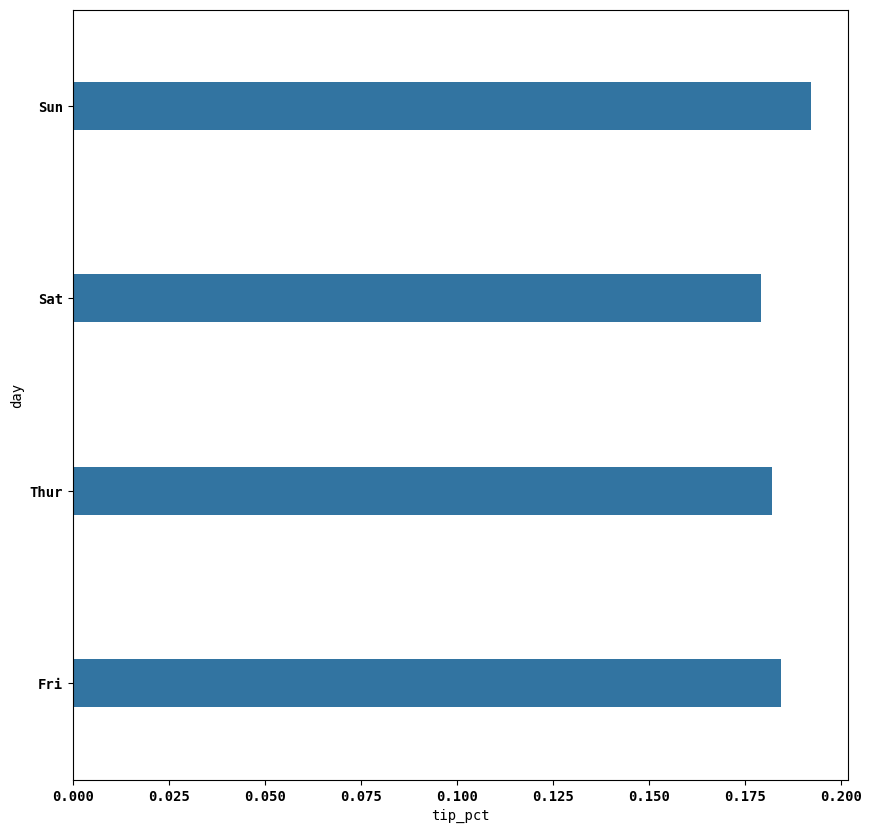

In [170]:
sns.barplot(
    x='tip_pct', y='day', data=tips, orient='h',
    estimator=np.median, errorbar=None, width=0.25
)

`seaborn.barplot` has a hue option that enables us to split by an additional categorical
value

<Axes: xlabel='tip_pct', ylabel='day'>

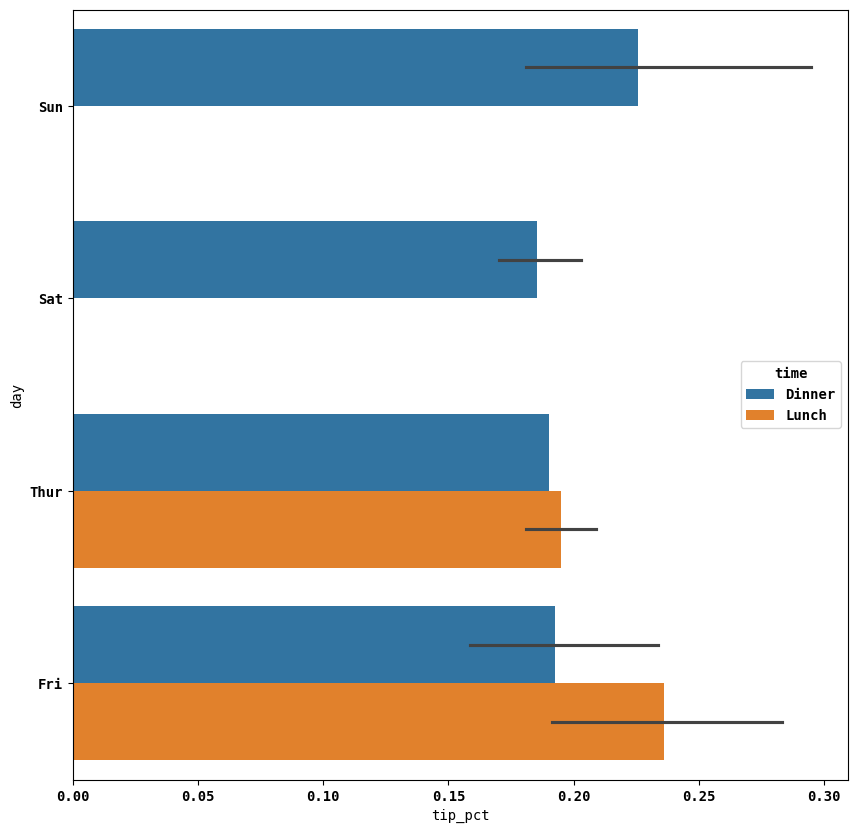

In [171]:
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

Notice that seaborn has automatically changed the aesthetics of plots: the default
color palette, plot background, and grid line colors. You can switch between different
plot appearances using `seaborn.set`:

In [172]:
sns.set(style="whitegrid")

<Axes: xlabel='tip_pct', ylabel='day'>

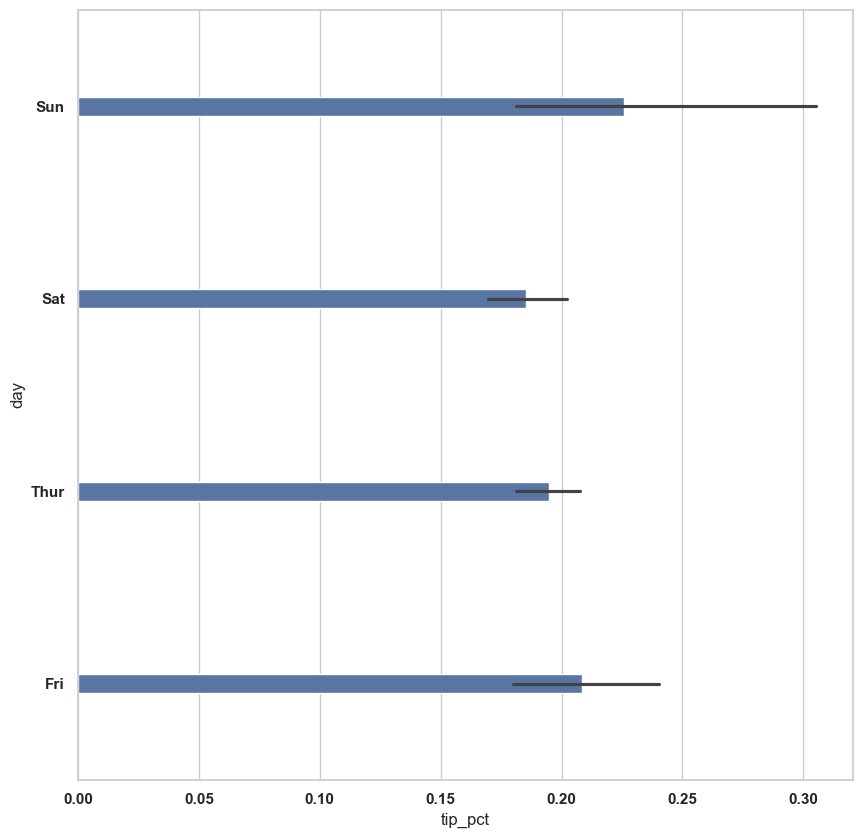

In [174]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h', errorbar=('ci', 95), width = 0.1)

In [175]:
sns.set(style="dark")

<Axes: xlabel='tip_pct', ylabel='day'>

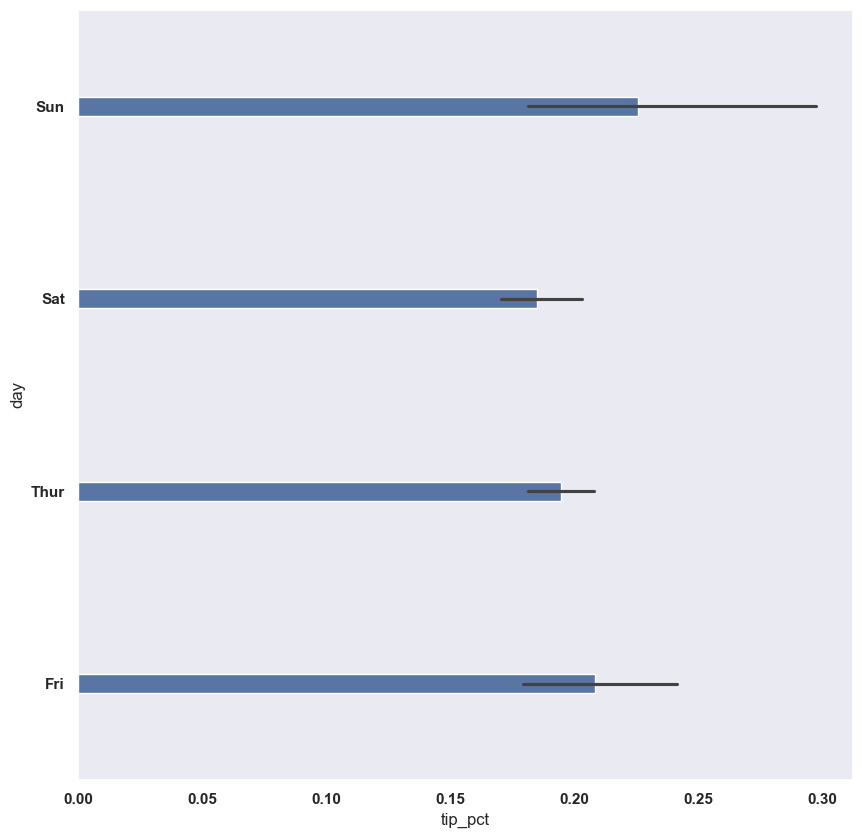

In [176]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h', errorbar=('ci', 95), width = 0.1)

### Histograms and Density Plots

A histogram is a kind of bar plot that gives a discretized display of value frequency.
The data points are split into discrete, evenly spaced bins, and the number of data
points in each bin is plotted. Using the tipping data from before, we can make a histogram
of tip percentages of the total bill using the `plot.hist` method on the Series

<Axes: ylabel='Frequency'>

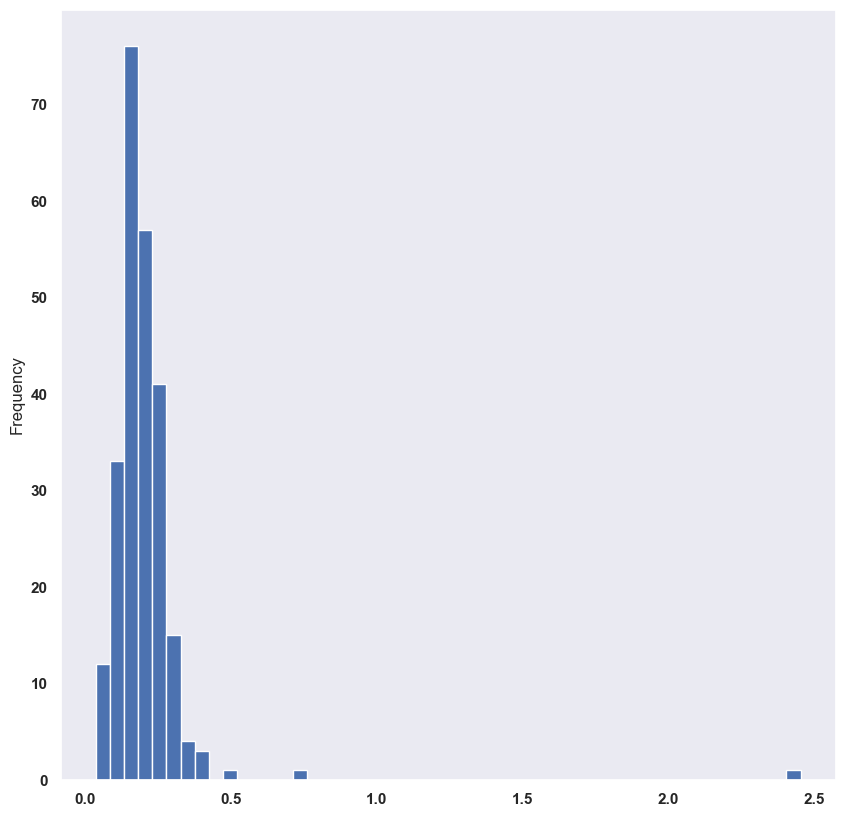

In [177]:
tips['tip_pct'].plot.hist(bins=50)

A related plot type is a density plot, which is formed by computing an estimate of a
continuous probability distribution that might have generated the observed data. The
usual procedure is to approximate this distribution as a mixture of “kernels”—that is,
simpler distributions like the normal distribution. Thus, density plots are also known
as kernel density estimate (KDE) plots. Using `plot.kde` makes a density plot using
the conventional mixture-of-normals estimate

<Axes: ylabel='Density'>

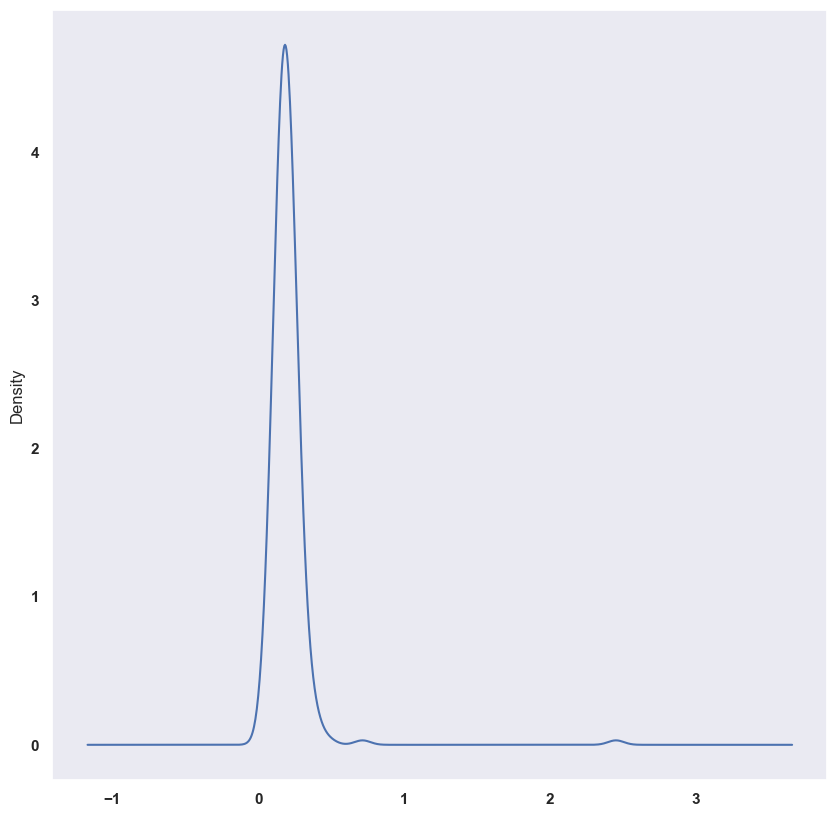

In [179]:
tips['tip_pct'].plot.density()

Seaborn makes histograms and density plots even easier through its `distplot`
method, which can plot both a histogram and a continuous density estimate simultaneously.
As an example, consider a bimodal distribution consisting of draws from
two different standard normal distributions (see Figure 9-23):

In [180]:
comp1 = np.random.normal(0, 1, size=200)

In [181]:
comp2 = np.random.normal(10, 2, size=200)

In [182]:
values = pd.Series(np.concatenate([comp1, comp2]))

In [183]:
values.head()

0    0.065474
1   -0.537839
2    0.454820
3    1.412545
4   -0.448469
dtype: float64

C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_31464\3498537128.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(values, bins=100, color='k')


<Axes: ylabel='Density'>

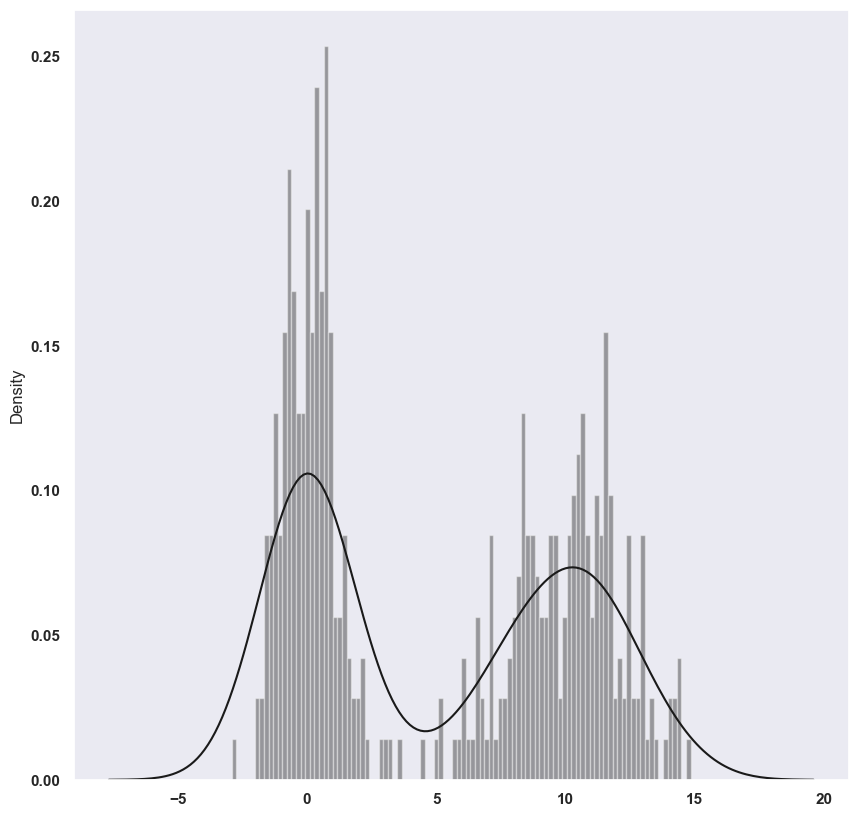

In [184]:
sns.distplot(values, bins=100, color='k')

---

##### What This Warning Means

You are seeing this warning because **`sns.distplot()` is deprecated** in Seaborn and **will be removed in version 0.14.0**.

```text
UserWarning:
`distplot` is a deprecated function and will be removed in seaborn v0.14.0.
```

This means:

*   Your code **still runs today**
*   But it **will break in future Seaborn versions**
*   Seaborn is telling you what to use **instead**

##### Why `distplot` Was Deprecated

`distplot` tried to do **too many things at once**:

*   Histogram
*   KDE (density curve)
*   Rug plot

Seaborn’s newer API separates concerns more clearly:

*   **Figure-level plotting** → `displot`
*   **Axes-level plotting** → `histplot` and `kdeplot`

This makes plots:

*   Easier to customize
*   More consistent with the rest of Seaborn
*   More flexible for multi-plot figures

##### Direct Replacement for Your Code (Most Common Case)

Your original code:

```python
sns.distplot(values, bins=100, color='k')
```

✅ **Recommended replacement using `histplot`** (closest match):

```python
sns.histplot(values, bins=100, color='k', kde=True)
```

This produces:

*   Histogram ✅
*   KDE curve ✅
*   Single axes (like `distplot`) ✅

##### When to Use `histplot` vs `displot`

###### Use `histplot` (Axes-level, most similar to `distplot`)

Use this when:

*   You are plotting on an existing `matplotlib` axis
*   You want simple, inline plots

Example:

```python
import seaborn as sns

sns.histplot(values, bins=100, kde=True, color='k')
```

###### Use `displot` (Figure-level, more powerful)

Use this when:

*   You want FacetGrid-style plots
*   You want multiple subplots automatically

Example:

```python
sns.displot(values, bins=100, kde=True, color='k')
```

Note:

*   `displot` creates its **own figure**
*   You cannot easily combine it with `plt.subplot()`

##### If You Want Only One Component

###### Histogram only

```python
sns.histplot(values, bins=100, color='k', kde=False)
```

###### KDE only

```python
sns.kdeplot(values, color='k', fill=True)
```

###### Rug plot (optional add-on)

```python
sns.histplot(values, bins=100, kde=True)
sns.rugplot(values, color='k')
```

##### Summary Mapping (Old → New)

```text
sns.distplot(...)        ❌ deprecated
sns.histplot(..., kde=True) ✅ recommended (axes-level)
sns.displot(..., kde=True)  ✅ recommended (figure-level)
```

##### Final Recommendation

For **minimal code change and future safety**, replace:

```python
sns.distplot(values, bins=100, color='k')
```

with:

```python
sns.histplot(values, bins=100, kde=True, color='k')
```

This is the **closest 1-to-1 replacement** and will continue to work in all future Seaborn versions.




----

<Axes: ylabel='Count'>

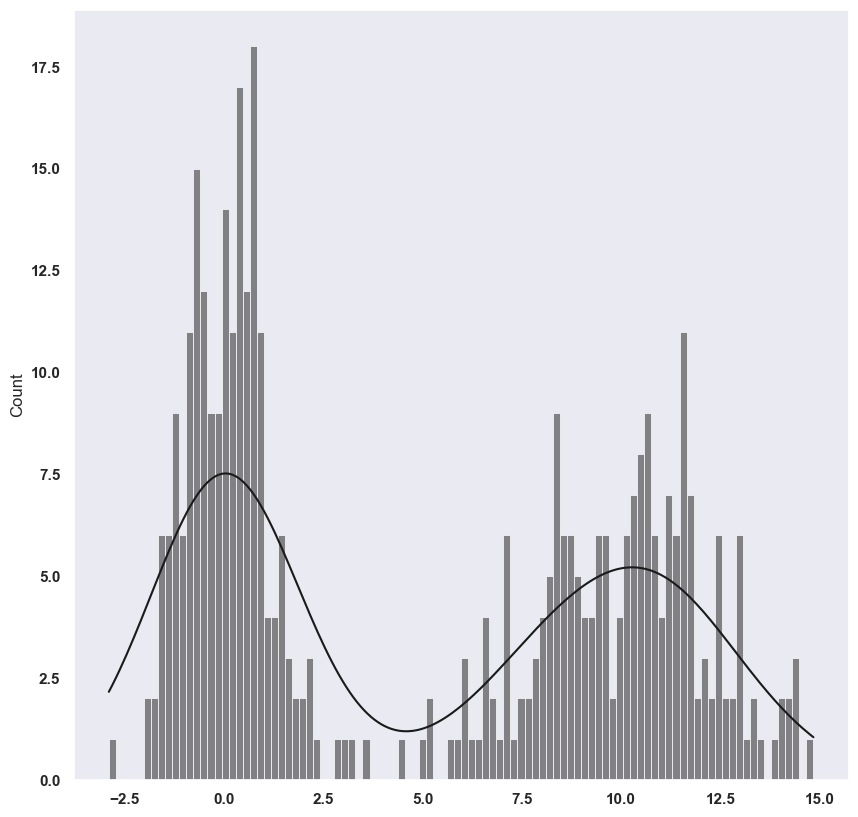

In [185]:
sns.histplot(values, bins=100, kde=True, color='k')

---

### Scatter or Point Plots

Point plots or scatter plots can be a useful way of examining the relationship between
two one-dimensional data series. For example, here we load the `macrodata` dataset
from the statsmodels project, select a few variables, then compute log differences:

In [188]:
macro = pd.read_csv('examples/macrodata.csv')


In [189]:
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]

In [190]:
trans_data = np.log(data).diff().dropna()

In [193]:
trans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


We can then use seaborn’s `regplot` method, which makes a scatter plot and fits a linear
regression line

In [192]:
sns.regplot('m1', 'unemp', data=trans_data)

TypeError: regplot() got multiple values for argument 'data'

<Axes: xlabel='m1', ylabel='unemp'>

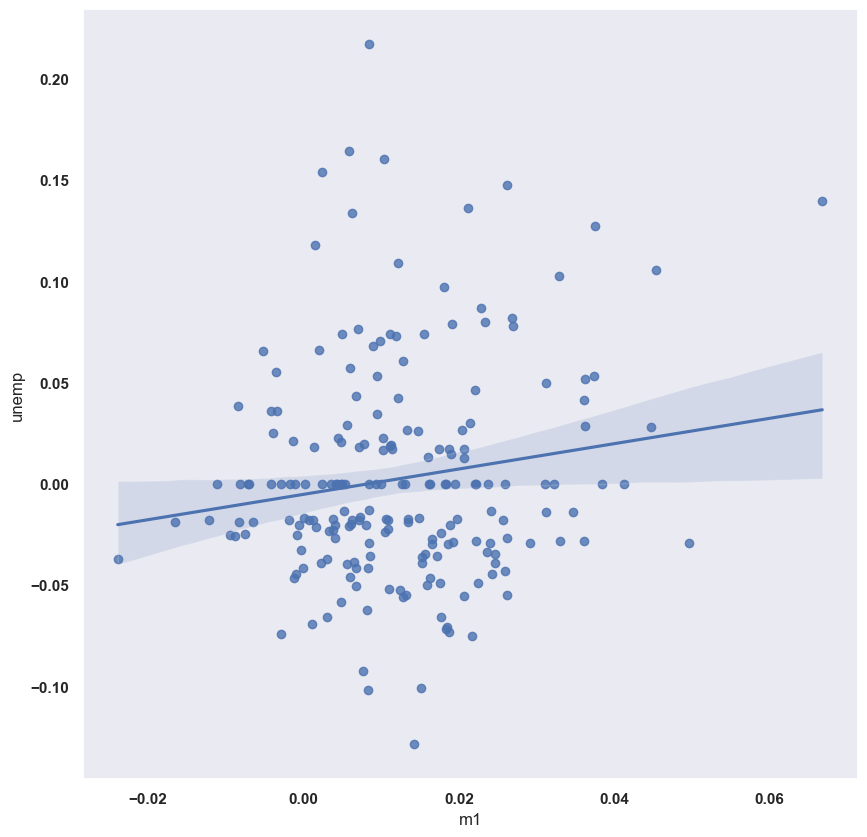

In [194]:
sns.regplot(x='m1', y='unemp', data=trans_data)

---

##### Why You’re Seeing This Error

You called:

```python
sns.regplot('m1', 'unemp', data=trans_data)
```

In recent Seaborn versions (≥ 0.12), many functions (including `regplot`) use **keyword-only arguments** for `x` and `y`. When you pass `'m1'` and `'unemp'` **positionally**, Seaborn interprets them in a way that conflicts with the explicit `data=` argument, leading to:

    TypeError: regplot() got multiple values for argument 'data'

##### The Correct Fix (Use Keyword Arguments)

Change your call to explicitly name `x` and `y`:

```python
sns.regplot(x='m1', y='unemp', data=trans_data)
```

This resolves the ambiguity and works across modern Seaborn versions.

##### Additional Tips (Common Gotchas)

*   **Ensure no missing values** in the selected columns:
    ```python
    sns.regplot(x='m1', y='unemp', data=trans_data.dropna(subset=['m1', 'unemp']))
    ```
*   **Make sure columns are numeric** (not object dtype):
    ```python
    trans_data[['m1', 'unemp']] = trans_data[['m1', 'unemp']].apply(pd.to_numeric, errors='coerce')
    ```
*   **Customize the fit** (scatter size, line color, confidence interval):
    ```python
    sns.regplot(
        x='m1', y='unemp', data=trans_data,
        scatter_kws={'s': 20, 'alpha': 0.6},
        line_kws={'color': 'crimson', 'lw': 2},
        ci=95  # or ci=None to remove the band
    )
    ```

##### If You’re Using Seaborn’s New Objects API (Optional)

Seaborn’s **objects** interface offers a more composable style:

```python
import seaborn.objects as so

(
    so.Plot(trans_data, x='m1', y='unemp')
      .add(so.Scatter(alpha=0.6, pointsize=20))
      .add(so.Line(color='crimson'), so.PolyFit(1))  # linear regression fit
)
```

This is handy if you plan to layer more elements or facet the plot later.

##### Quick Sanity Checks for Your Data

Because `trans_data` came from `np.log(...).diff()`, it can include NaNs (first diff) and potentially infs if any original values were nonpositive (before log). It’s good practice to clean:

```python
plot_df = trans_data[['m1', 'unemp']].replace([np.inf, -np.inf], np.nan).dropna()
sns.regplot(x='m1', y='unemp', data=plot_df)
```

##### TL;DR

Use keyword args:

```python
sns.regplot(x='m1', y='unemp', data=trans_data)
```

This eliminates the “multiple values for argument 'data'” error and aligns with Seaborn’s current API.


---

In exploratory data analysis it’s helpful to be able to look at all the scatter plots among
a group of variables; this is known as a pairs plot or scatter plot matrix. Making such a
plot from scratch is a bit of work, so seaborn has a convenient pairplot function,
which supports placing histograms or density estimates of each variable along the
diagonal.



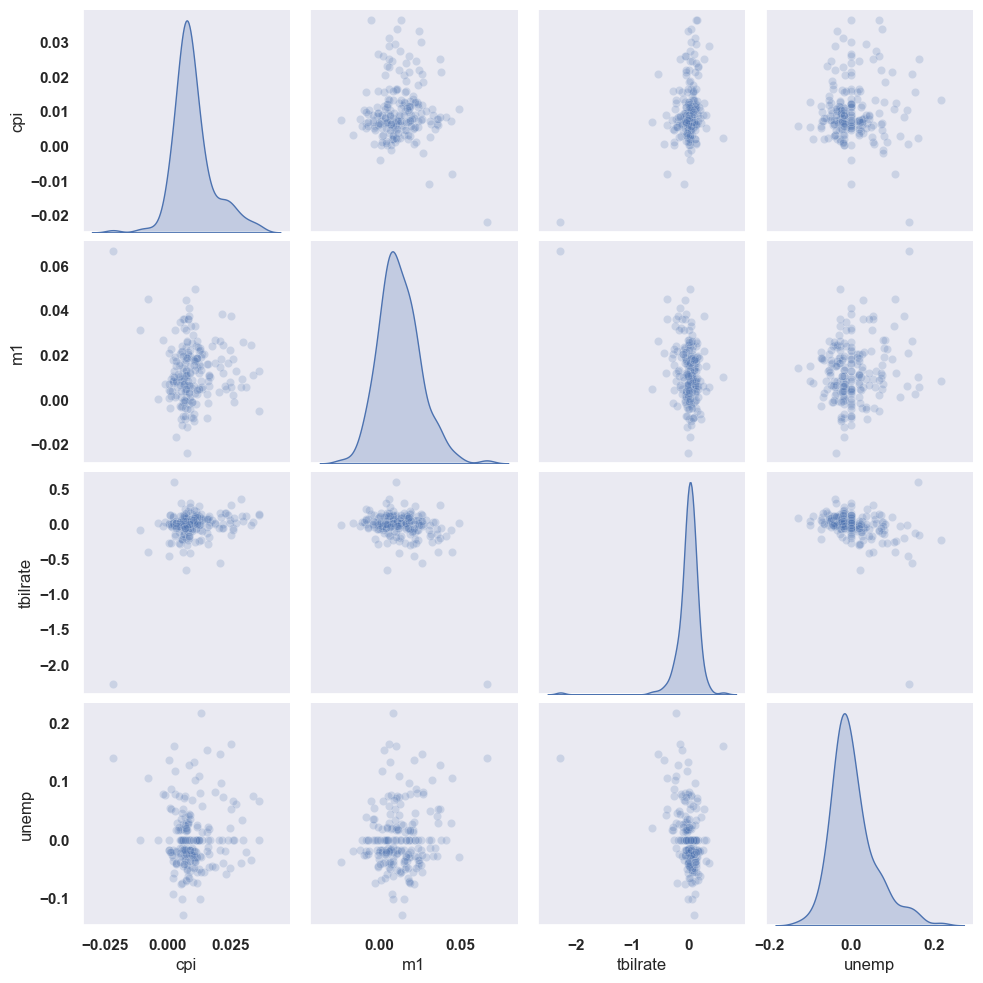

In [195]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha': 0.2})

You may notice the `plot_kws` argument. This enables us to pass down configuration
options to the individual plotting calls on the off-diagonal elements. Check out the
`seaborn.pairplot` docstring for more granular configuration options.

---

### Facet Grids and Categorical Data

What about datasets where we have additional grouping dimensions? One way to visualize
data with many categorical variables is to use a facet grid. Seaborn has a useful
built-in function `factorplot` that simplifies making many kinds of faceted plots.

In [198]:
sns.factorplot(x='day', y='tip_pct', hue='time', col='smoker',kind='bar', data=tips[tips.tip_pct < 1])

AttributeError: module 'seaborn' has no attribute 'factorplot'

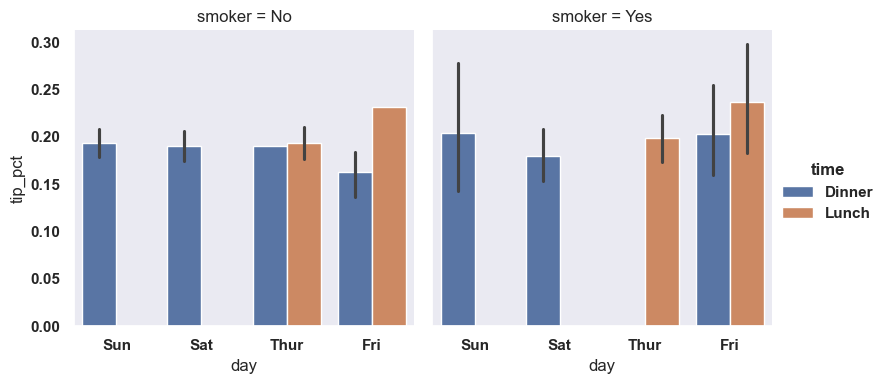

In [199]:

sns.catplot(
    data=tips[tips['tip_pct'] < 1],
    x='day', y='tip_pct',
    hue='time',
    col='smoker',
    kind='bar',
    height=4, aspect=1
)


##### Why You’re Getting `AttributeError: module 'seaborn' has no attribute 'factorplot'`

`factorplot` was **deprecated** and then **removed** from Seaborn. In modern Seaborn versions (≥ 0.11), the direct replacement is **`catplot`** (the figure‑level categorical plotting function). That’s why calling `sns.factorplot(...)` now raises an `AttributeError`.

***

##### Quick Fix: Replace `factorplot` with `catplot` (Bar Kind)

Your original call:

```python
sns.factorplot(x='day', y='tip_pct', hue='time', col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])
```

Use this instead:

```python
import seaborn as sns

sns.catplot(
    data=tips[tips['tip_pct'] < 1],
    x='day', y='tip_pct',
    hue='time',
    col='smoker',
    kind='bar',
    height=4, aspect=1
)
```

*   `catplot` is **figure‑level** (creates a FacetGrid under the hood).
*   `kind='bar'` computes and plots the **mean** of `tip_pct` per category by default (with uncertainty intervals).
*   In Seaborn ≥ 0.12, control intervals with `errorbar` (e.g., `errorbar=None`).

If you want the **median** instead of mean:

```python
import numpy as np
sns.catplot(
    data=tips[tips['tip_pct'] < 1],
    x='day', y='tip_pct',
    hue='time', col='smoker',
    kind='bar',
    estimator=np.median,
    errorbar=None
)
```

***

##### Axes‑Level Alternative: `barplot` + Faceting Manually

If you prefer to manage subplots yourself (axes‑level), you can facet by `smoker` manually:

```python
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(
    tips[tips['tip_pct'] < 1],
    col='smoker', hue='time', height=4, aspect=1, sharey=True
)
g.map_dataframe(
    sns.barplot, x='day', y='tip_pct', errorbar=('ci', 95)
)
g.add_legend()
```

This gives you more control over axes but requires a bit more code.

***

##### New Objects API (Optional, Very Flexible)

Seaborn’s newer **Objects API** offers a composable approach:

```python
import seaborn.objects as so

(
    so.Plot(tips.query('tip_pct < 1'), x='day', y='tip_pct', color='time')
      .facet(col='smoker')
      .add(so.Bar(), so.Agg('mean'))   # mean by default
      .layout(size=(800, 300))
)
```

You can swap `so.Agg('mean')` for `'median'`, and layer other elements easily.

***

##### Control of Error Bars (Seaborn ≥ 0.12)

*   Disable intervals:
    ```python
    sns.catplot(..., kind='bar', errorbar=None)
    ```
*   Use standard error:
    ```python
    sns.catplot(..., kind='bar', errorbar=('se', 1))
    ```
*   Change CI:
    ```python
    sns.catplot(..., kind='bar', errorbar=('ci', 95))
    ```

For older Seaborn (< 0.12), the parameter is `ci=...` instead of `errorbar`.

***

##### Sanity Checks to Avoid Plot Failures

*   Ensure no NaN/inf in `tip_pct` after filtering:
    ```python
    df = tips.loc[tips['tip_pct'] < 1, ['day', 'time', 'smoker', 'tip_pct']].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    sns.catplot(data=df, x='day', y='tip_pct', hue='time', col='smoker', kind='bar')
    ```
*   Confirm column dtypes are numeric for `y`:
    ```python
    df['tip_pct'] = pd.to_numeric(df['tip_pct'], errors='coerce')
    ```

***

##### TL;DR

*   `factorplot` is **gone** → use **`catplot`**.
*   Your one‑line replacement:
    ```python
    sns.catplot(data=tips[tips['tip_pct'] < 1],
                x='day', y='tip_pct',
                hue='time', col='smoker',
                kind='bar')
    ```
*   Use `errorbar=...` (≥ 0.12) or `ci=...` (< 0.12) to control intervals.


---

Instead of grouping by `'time'` by different bar colors within a facet, we can also
expand the facet grid by adding one row per `time` value

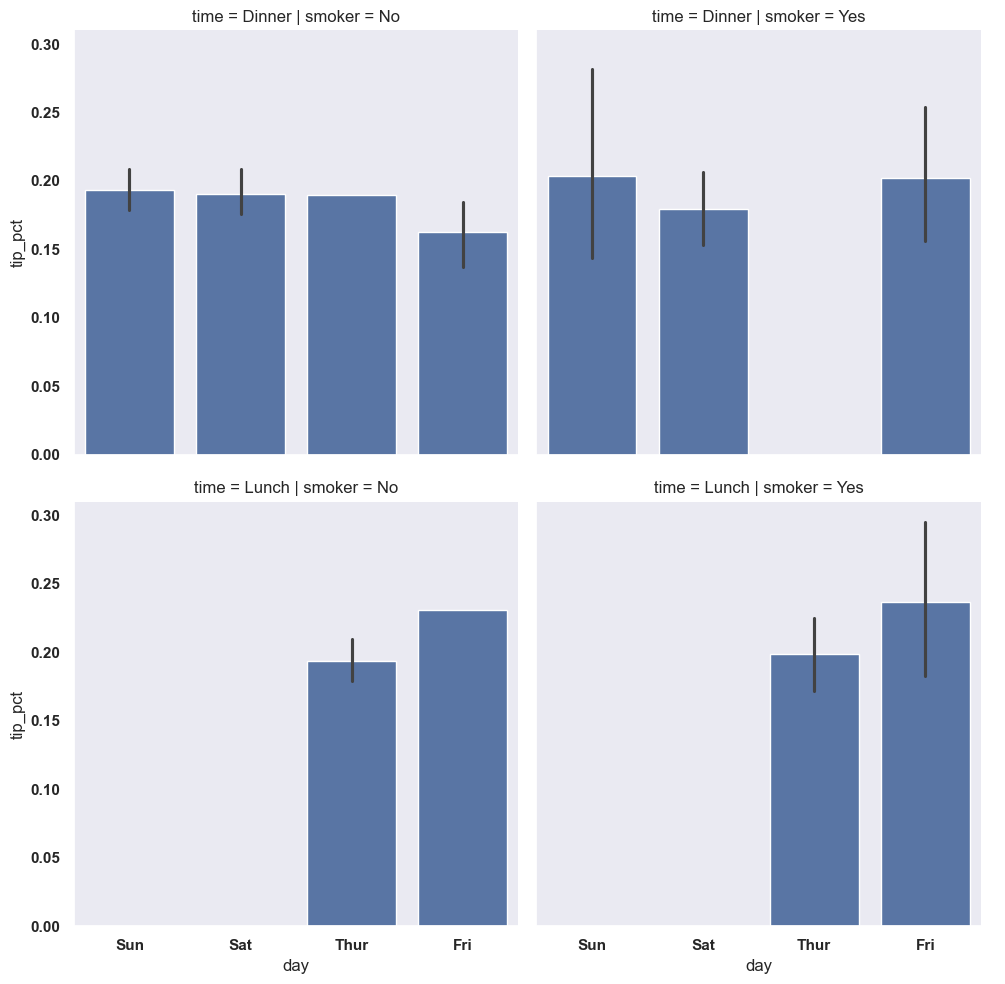

In [202]:
sns.catplot(x='day', y='tip_pct', row='time',
               col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

`factorplot` supports other plot types that may be useful depending on what you are
trying to display. For example, box plots (which show the median, quartiles, and outliers)
can be an effective visualization type

In [203]:
sns.factorplot(x='tip_pct', y='day', kind='box',data=tips[tips.tip_pct < 0.5])

AttributeError: module 'seaborn' has no attribute 'factorplot'

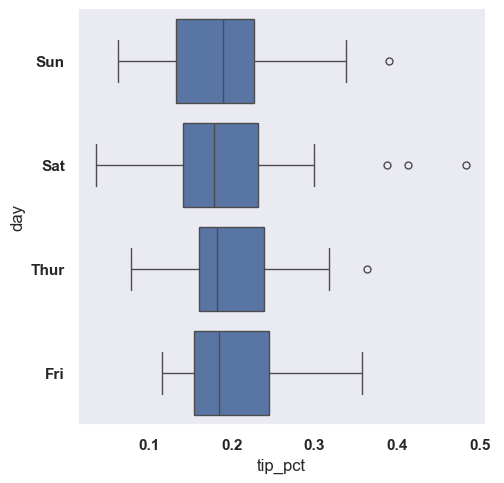

In [204]:
sns.catplot(x='tip_pct', y='day', kind='box',data=tips[tips.tip_pct < 0.5])

You can create your own facet grid plots using the more general `seaborn.FacetGrid`
class. See the seaborn documentation for more. (https://seaborn.pydata.org/)

## 9.3 Other Python Visualization Tools

As is common with open source, there are a plethora of options for creating graphics
in Python (too many to list). Since 2010, much development effort has been focused
on creating interactive graphics for publication on the web. With tools like [Bokeh](https://docs.bokeh.org/en/latest/) and
[Plotly](https://github.com/plotly/plotly.py), it’s now possible to specify dynamic, interactive graphics in Python that are
destined for a web browser.
For creating static graphics for print or web, I recommend defaulting to matplotlib
and add-on libraries like pandas and seaborn for your needs. For other data visualization
requirements, it may be useful to learn one of the other available tools out there.
I encourage you to explore the ecosystem as it continues to involve and innovate into
the future.

## 9.4 Conclusion

The goal of this chapter was to get your feet wet with some basic data visualization
using pandas, matplotlib, and seaborn. If visually communicating the results of data
analysis is important in your work, I encourage you mto seek out resources to learn
more about effective data visualization. It is an active field of research and you can
practice with many excellent learning resources available online and in print form.
In the next chapter, we turn our attention to data aggregation and group operations
with pandas.